# ML4N - Group Project 7
# Analysing Adversarial Attacks on Tabular Data Classifiers

In [107]:
# import needed python libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D 


import torch # type: ignore
import torch.nn.functional as F
import random
from torch.utils.data import TensorDataset, DataLoader
import torchvision

import plotly.offline as py 
import plotly.express as px
import plotly.graph_objs as go # it's like "plt" of matplot
import plotly.subplots as tls # It's useful to we get some tools of plotly


# Change the default font family
rcParams['font.family'] = 'DejaVu Sans'

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from plotly.subplots import make_subplots
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils._testing import ignore_warnings
from art.estimators.classification import PyTorchClassifier as ARTClassifier
from art.estimators.classification import PyTorchClassifier # type: ignore
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent # type: ignore
from art.defences.trainer import AdversarialTrainer
from art.attacks.evasion import ProjectedGradientDescent
from art.attacks.evasion import BasicIterativeMethod
from art.attacks.evasion import BoundaryAttack

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from collections import Counter # To do counter of some features
from torch import nn
from imblearn.over_sampling import SMOTE # type: ignore

from scipy.stats import uniform
from xgboost import XGBClassifier

#### this code, allow us to work with offline plotly version
py.init_notebook_mode(connected=True) 

#### to avoid some redundant warning during cross-validation due to parameters incompatibility and also eventual packets'versions mismatch
import warnings
warnings.filterwarnings('ignore')

# matplotlib defaults
plt.style.use("fivethirtyeight")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
    grid=True,
)


In [108]:
# confusion matrix
def confusion_matri(actual, predicted):
    cm = confusion_matrix(actual, predicted)
    tn, fp, fn, tp = cm.ravel()
    #plot confusion matrix
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels =['Bad credit','Good credit'],
                yticklabels =['Bad credit','Good credit'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted lable')
    plt.title("Confusion Matrix")
    plt.show()
    return tn,fp,fn,tp

# plotting roc-auc curve
def draw_roc(actual, proba):
    fpr, tpr, thresholds = roc_curve(actual, proba,drop_intermediate=False)
    auc_score = roc_auc_score(actual, proba)
    # plot the curve
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label="ROC curve(area={})".format(round(auc_score,2)))
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(visible=True, color='wheat', linestyle='--')
    plt.legend(loc="lower right")
    plt.title("ROC-AUC Curve")
    plt.show()
    return fpr, tpr, thresholds

In [109]:
# Funzione per calcolare le distanze euclidee (già fornita in precedenza)
def calculate_euclidean_distances(original_data, adversarial_data):
    original_data = np.array(original_data)
    adversarial_data = np.array(adversarial_data)
    
    if original_data.shape != adversarial_data.shape:
        raise ValueError("The shape of original_data and adversarial_data must be the same.")
    
    distances = np.linalg.norm(original_data - adversarial_data, axis=1)
    return distances

# 1 Data exploration and preprocessing

## 1.1 Dataset Acquisition ###

---
Begin by downloading the [German Credit Risk dataset](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

In [110]:
#### List of Attributes for dataset acquired from german.doc
#### good/bad is the label 1 means good customer while 2 means bad
attributes = ["Status_account",
              "Duration", 
              "Credit_history",
              "Purpose",
              "Credit_amount",
              "Savings_account_bonds",
              "Employment_since",
              "Install_rate",
              "Personal_status_sex",
              "debtors_guarantors",
              "Present_residence_since",
              "Property",
              "Age",
              "Other_install_plans",
              "Housing",
              "No_credits",
              "Job",
              "No_people_liable",
              "Telephone",
              "foreign_worker",
              "good_bad"] 

numeric_features = ["Duration",
                    "Credit_amount",
                    "Install_rate",
                    "Present_residence_since",
                    "Age",
                    "No_credits",
                    "No_people_liable",
                    "good_bad"] 

categorical_features = attributes.copy()
for el in numeric_features:
    categorical_features.remove(el)
numeric_features.remove("good_bad")

#### Acquiring dataset from german.data file
df = pd.read_csv("statlog+german+credit+data/german.data", sep=' ', names = attributes)
df

,Status_account,Duration,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Employment_since,Install_rate,Personal_status_sex,debtors_guarantors,...,Property,Age,Other_install_plans,Housing,No_credits,Job,No_people_liable,Telephone,foreign_worker,good_bad
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


### We create a hard copy To use in the visualization part.

In [111]:
df_credit = df.copy()

### The dataset

The dataset is composed of both categorical and numerical features which are used to describe the socio-economic situation of the credit applicants, the categorical ones are codified with alpha numerical codes.As an example we report the meaning of some of the features of the dataset

**Existing Checking Account (Qualitative)**

Status of existing checking account i.e. range of money in existing checking account (if present)

| Value | Description|
| --- | --- |
| A11 | .. < 0 DM | 
| A12 | 0 <= ... < 200 DM | 
| A13 | ... >= 200 DM / salary assignments for at least 1 year |
| A14 | no checking account|

Note: DM stands for Deutsche Marks.

**Month Duration (Numerical)**

Duration in month of the asked loan

**Purpose (Qualitative)**

Purpose of the requested loan

| Value | Description|
| --- | --- |
| A40 | car (new)
| A41 | car (used)
| A42 | furniture/equipment
| A43 | radio/television
| A44 | domestic appliances
| A45 | repairs
| A46 | education
| A47 | vacation
| A48 | retraining
| A49 | business
| A410 | others

**Credit Amount (Numerical)**

Amount of money requested for the credit

**Personal Status and Sex (Qualitative)**

| Value | Description|
| --- | --- |
|A91 | male : divorced/separated
|A92 | female : divorced/separated/married
|A93 | male : single
|A94 | male : married/widowed
|A95 | female : single

**Property (Qualitative)**

Type of property owned by the applicant

| Value | Description|
| --- | --- |
|A121 | real estate
|A122 | if not A121 : building society savings agreement/ life insurance
|A123 | if not A121/A122 : car or other, not in attribute 6
|A124 | unknown / no property

**Age (Numerical)**

Age in years

**Housing (Qualitative)**

| Value | Description|
| --- | --- |
|A151 | rent
|A152 | own
|A153 | for free

**Existing credit number (Numerical)**

Number of existing credit at this bank

**Result (Response)**

| Value | Description|
| --- | --- |
|1 | good (applicant eligible for credit)
|2 | bad (applicant not eligible for credit)

As we can see the value used for describing the response are $1 \implies good$ result and $2 \implies bad$ result. 

With df.info() we can find if some data are missing

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Status_account           1000 non-null   object
 1   Duration                 1000 non-null   int64 
 2   Credit_history           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_amount            1000 non-null   int64 
 5   Savings_account_bonds    1000 non-null   object
 6   Employment_since         1000 non-null   object
 7   Install_rate             1000 non-null   int64 
 8   Personal_status_sex      1000 non-null   object
 9   debtors_guarantors       1000 non-null   object
 10  Present_residence_since  1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_install_plans      1000 non-null   object
 14  Housing                  1000 non-null   

With the describe method we can see some basics statistics about the quantitative features

In [113]:
df.describe()

,Duration,Credit_amount,Install_rate,Present_residence_since,Age,No_credits,No_people_liable,good_bad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [114]:
#Looking unique values
print(df.nunique())

Status_account               4
Duration                    33
Credit_history               5
Purpose                     10
Credit_amount              921
Savings_account_bonds        5
Employment_since             5
Install_rate                 4
Personal_status_sex          4
debtors_guarantors           3
Present_residence_since      4
Property                     4
Age                         53
Other_install_plans          3
Housing                      3
No_credits                   4
Job                          4
No_people_liable             2
Telephone                    2
foreign_worker               2
good_bad                     2
dtype: int64


Now we will now check the class distribution in the dataset to see whether there is some imbalance

In [115]:

# Positive labels
eligible= df["good_bad"] == 1
print(f"The percentage of those who are eligible for credit (good risk) is: {df[eligible].shape[0]/df.shape[0]}")

# Negative labels
not_eligible= df["good_bad"] == 2
print(f"The percentage of those who are not eligible for credit(bad risk) is: {df[not_eligible].shape[0]/df.shape[0]}")

# We can note a sligthly umbalance

The percentage of those who are eligible for credit (good risk) is: 0.7
The percentage of those who are not eligible for credit(bad risk) is: 0.3


## 1.2 Data Preprocessing ###

---
As a preprocessing step, convert categorical features to numerical features, e.g., by means of a one-hot
encoding, and apply a normalization to map all features between [0,1]. Assign labels to the dataset
indicating the true loan attribution outcomes for supervised learning. Clearly define categories or
classes representing loan approval or denial. Additionally, reserve 20% of the dataset for final testing
and assessment of the robustness of the models.

In [116]:

#### Using One Hot Encoding to transform categorical attributes into qualitative ones
df_encoded = pd.get_dummies(df, columns=categorical_features, dtype = int)

#### Normalization between [0,1]
scaler = MinMaxScaler()
df_scaled = df_encoded.copy()

#### Creation of the pandas dataframe of the normalized values
df_scaled.loc[:, df_scaled.columns != 'good_bad'] = scaler.fit_transform(df_scaled.loc[:, df_scaled.columns != 'good_bad'])
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns, index=df_encoded.index)

mask_bad = df_scaled["good_bad"] == 2 
df_scaled["good_bad"] = np.where(mask_bad, 0, 1)

features = df_scaled.columns.drop("good_bad")


X, X_test, y, y_test = train_test_split(
    df_scaled[features],
    df_scaled['good_bad'],
    stratify=df_scaled['good_bad'],
    train_size=0.8,
    random_state=15
)


In [117]:
df_scaled

,Duration,Credit_amount,Install_rate,Present_residence_since,Age,No_credits,No_people_liable,good_bad,Status_account_A11,Status_account_A12,...,Housing_A152,Housing_A153,Job_A171,Job_A172,Job_A173,Job_A174,Telephone_A191,Telephone_A192,foreign_worker_A201,foreign_worker_A202
0,0.029412,0.050567,1.000000,1.000000,0.857143,0.333333,0,1,1,0,...,1,0,0,0,1,0,0,1,1,0
1,0.647059,0.313690,0.333333,0.333333,0.053571,0.000000,0,0,0,1,...,1,0,0,0,1,0,1,0,1,0
2,0.117647,0.101574,0.333333,0.666667,0.535714,0.000000,1,1,0,0,...,1,0,0,1,0,0,1,0,1,0
3,0.558824,0.419941,0.333333,1.000000,0.464286,0.000000,1,1,1,0,...,0,1,0,0,1,0,1,0,1,0
4,0.294118,0.254209,0.666667,1.000000,0.607143,0.333333,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.117647,0.081765,0.666667,1.000000,0.214286,0.000000,0,1,0,0,...,1,0,0,1,0,0,1,0,1,0
996,0.382353,0.198470,1.000000,1.000000,0.375000,0.000000,0,1,1,0,...,1,0,0,0,0,1,0,1,1,0
997,0.117647,0.030483,1.000000,1.000000,0.339286,0.000000,0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
998,0.602941,0.087763,1.000000,1.000000,0.071429,0.000000,0,0,1,0,...,0,1,0,0,1,0,0,1,1,0


### From this moment on for our work we use as a  reference $1 \implies good$ and $0 \implies bad$. 

## 1.3 Exploratory Data Analysis ###
---
Delve into the dataset’s patterns using various visualization techniques, such as histograms of average values, scatter plots of most interesting features and correlation matrices. Provide insights into under-lying patterns and, most importantly, identify features significantly influencing loan risk classification

### For practical reason we move the Exploratory Data Analysis [to another file](./Adversarial%20Attack%20Exploratory%20Data%20Analysis.ipynb)

# 2 Unsupervised exploration and clustering #

## 2.1 Dimensionality reduction for data visualization ###

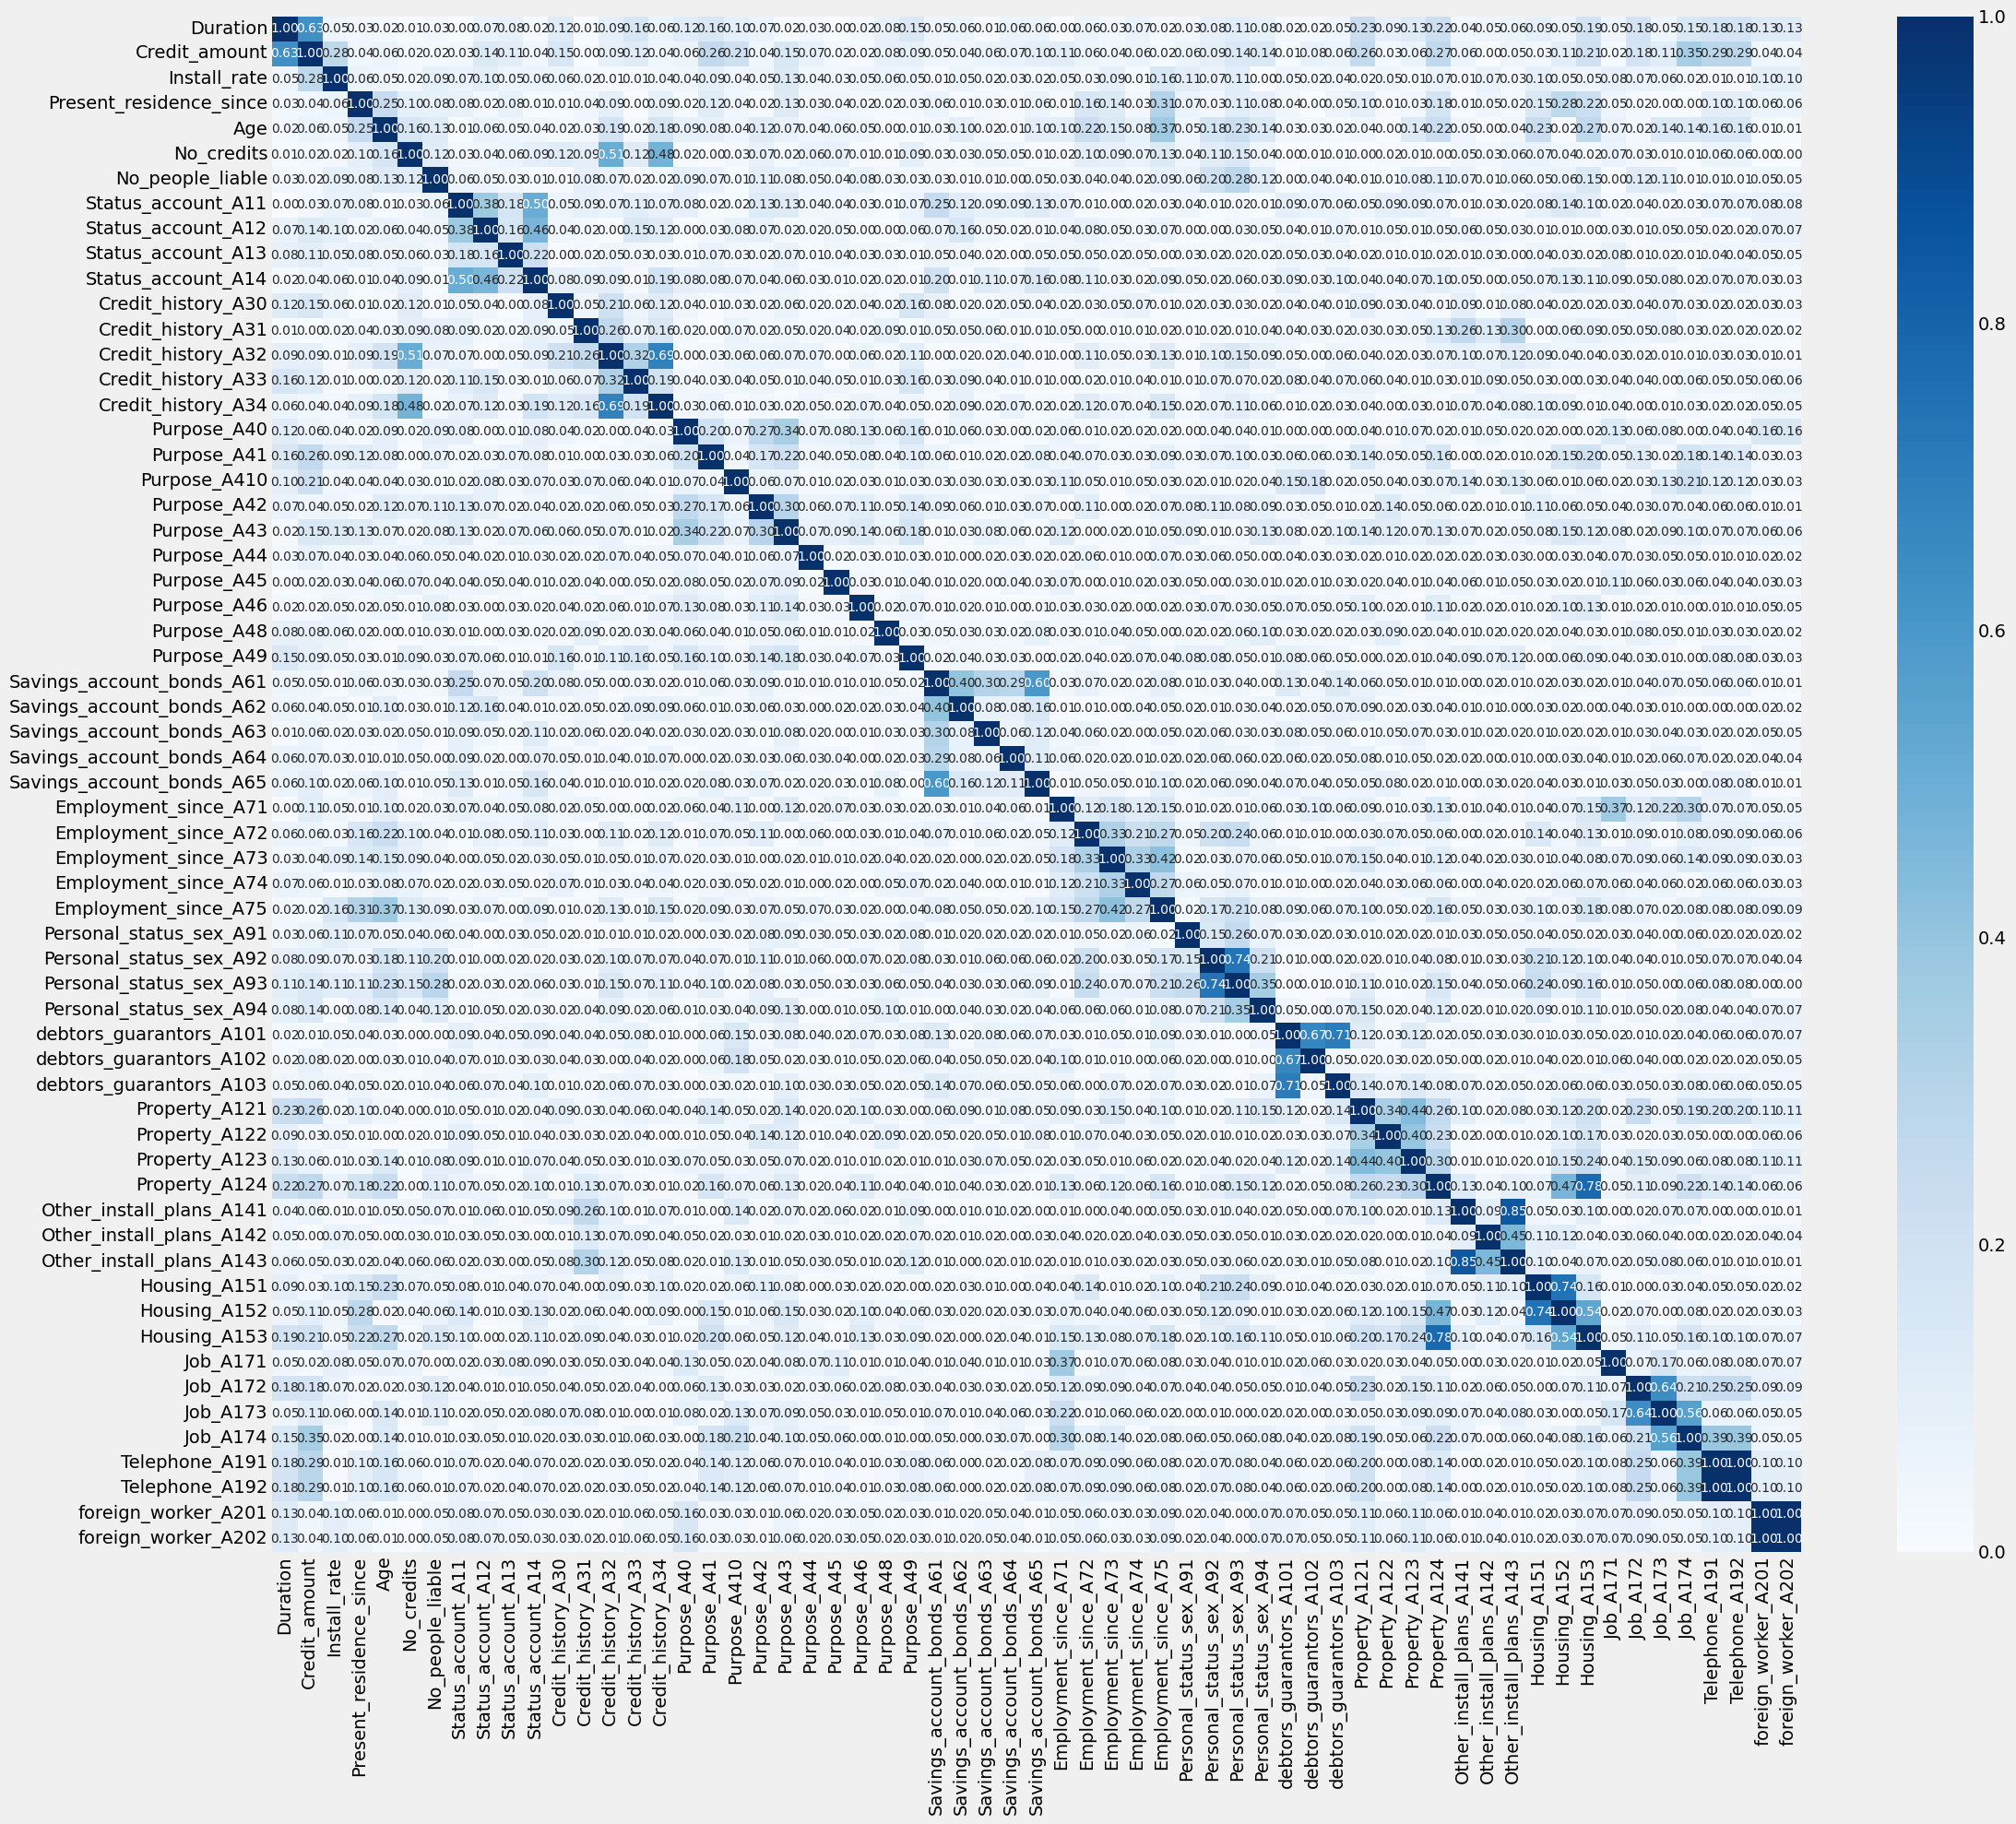

In [118]:
#### Apply dimensionality reduction techniques: t-Distributed Stochastic Neighbor Embedding (t-SNE)
#### and Principal Component Analysis (PCA) to reduce and visualize the data.

#### I compute the correlation between the features to see if there are any correlated features
correlation_analysis = X.corr().abs()

plt.figure(figsize = (24,20))
sns.heatmap(
    correlation_analysis,
    cmap="Blues",
    annot=True,
    fmt=".2f",  # Limits the numbers to 2 decimal places
    annot_kws={"size": 10}  # Increase the font size of annotations
    )
plt.show()

### 2.1.1 PCA

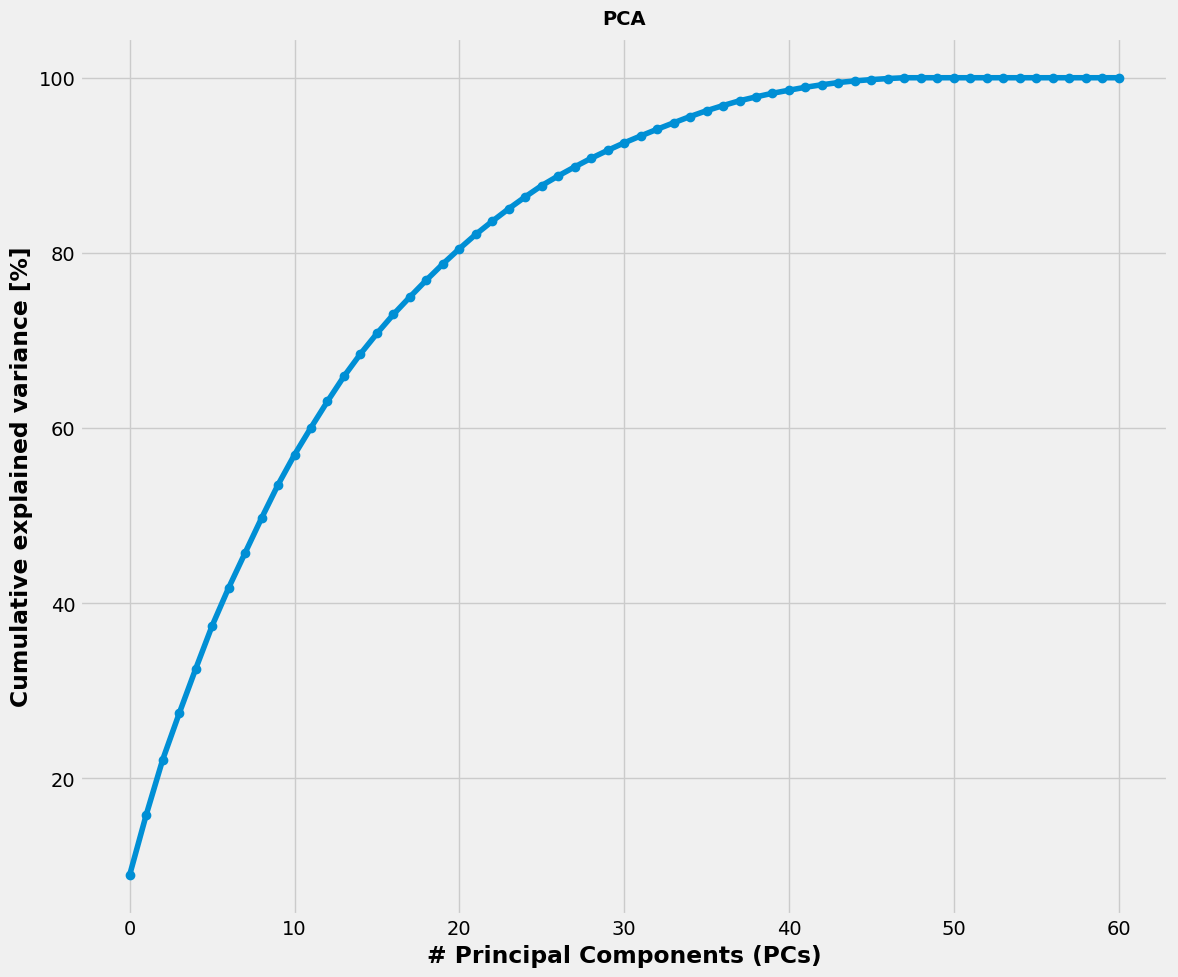

The variance at 30th component is:  92.56259748403582


In [119]:
#### PCA to check the variances
pca = PCA(random_state = 15)
pca.fit(df_scaled[features])

#### Compute the variability of the dataset, while the variable number keeps increasing
explained_variance = pca.explained_variance_ratio_
#### Representing the cumulative sum in percentage
perc_cumul_exp_var = np.cumsum(explained_variance) * 100

#### Make the plot of cumulative explained variance w.r.t. number of components
plt.figure(figsize=(12, 10))
plt.plot(perc_cumul_exp_var, marker='o')
plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')
plt.title("PCA")
plt.tight_layout()
plt.show()

print("The variance at 30th component is: ", perc_cumul_exp_var[30])


### SMOTE for oversampling

In [120]:
sm = SMOTE(random_state=60)
X_res, y_res = sm.fit_resample(X, y)

We have carried out further research and analysis on the PCA components that we report in this [file](Adversarial%20Attack%20test%20PCA%20components.ipynb)

In [121]:
pca = PCA(n_components = 30)
pca.fit(X_res)

X_PCA = pca.transform(X_res)
X_test_PCA = pca.transform(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

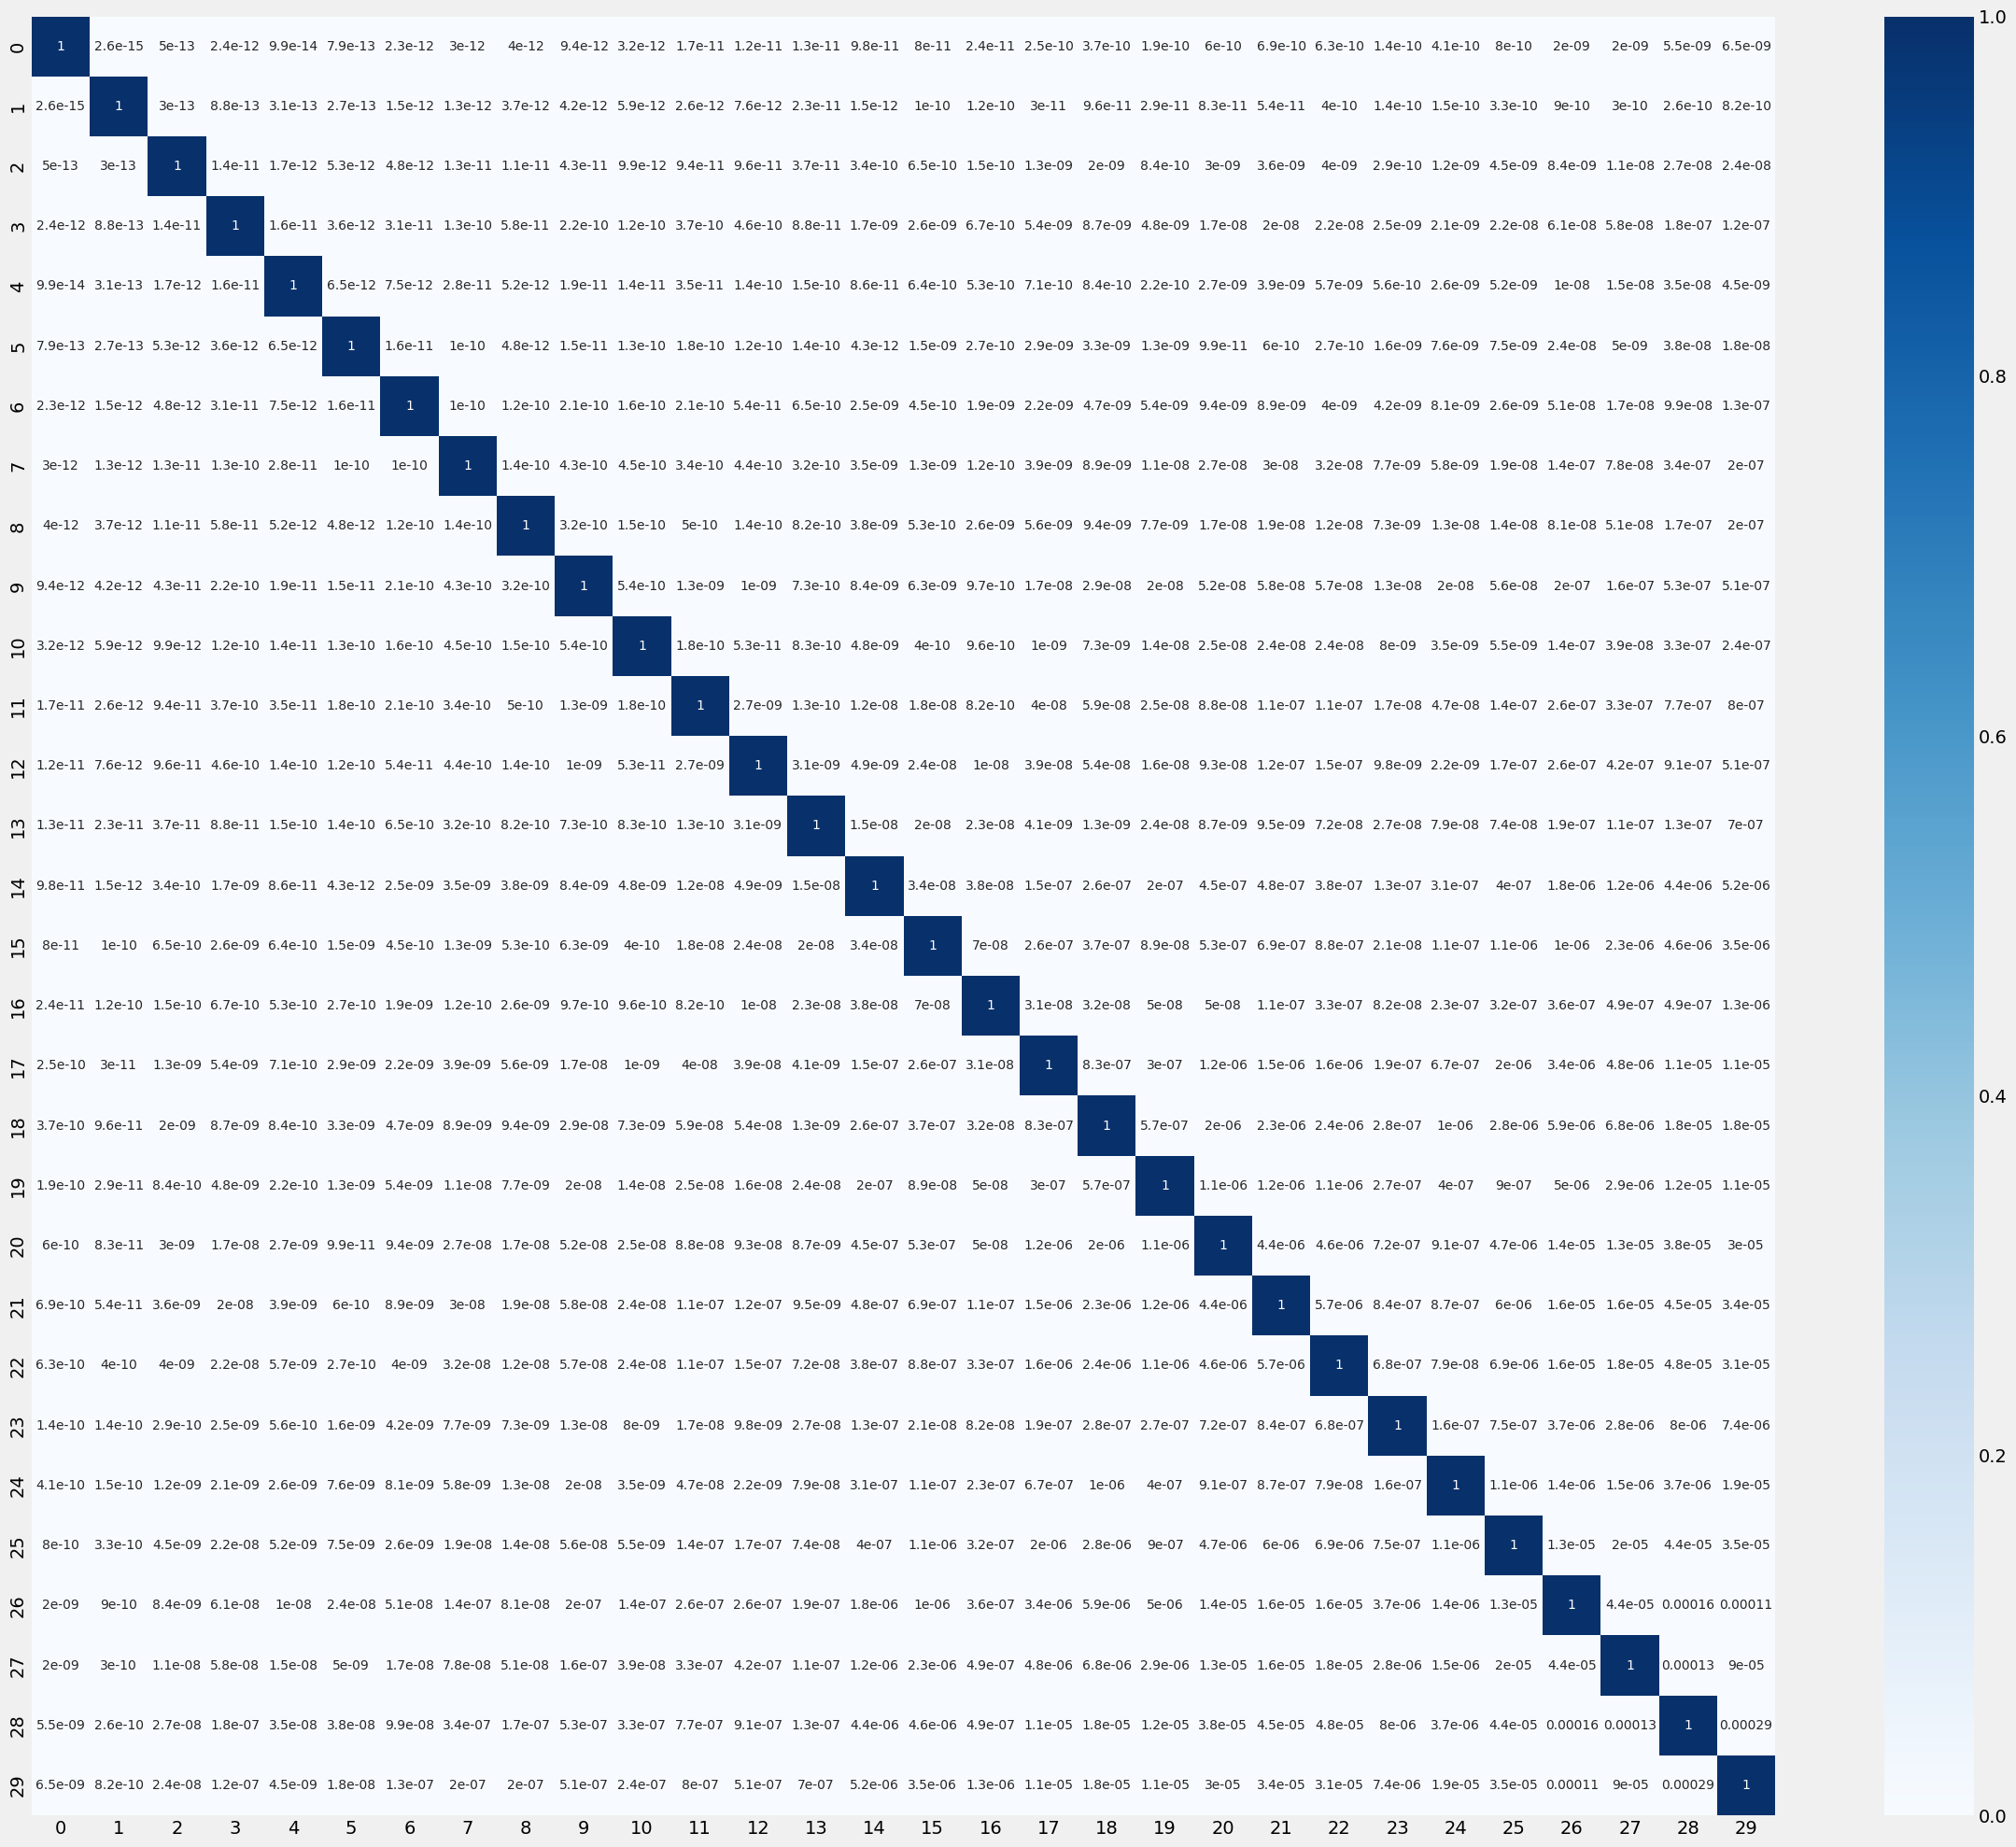

In [122]:
####Compute the correlation matrix after PCA
correlation_analysis = pd.DataFrame(X_PCA).corr().abs()
plt.figure(figsize = (24,20))
sns.heatmap(
    correlation_analysis, 
    cmap="Blues", 
    annot=True,
    annot_kws={"size": 10}  # Increase the font size of annotations
    )
plt.show
#### No more correlation between different features after PCA

### 2.1.2 T-sne

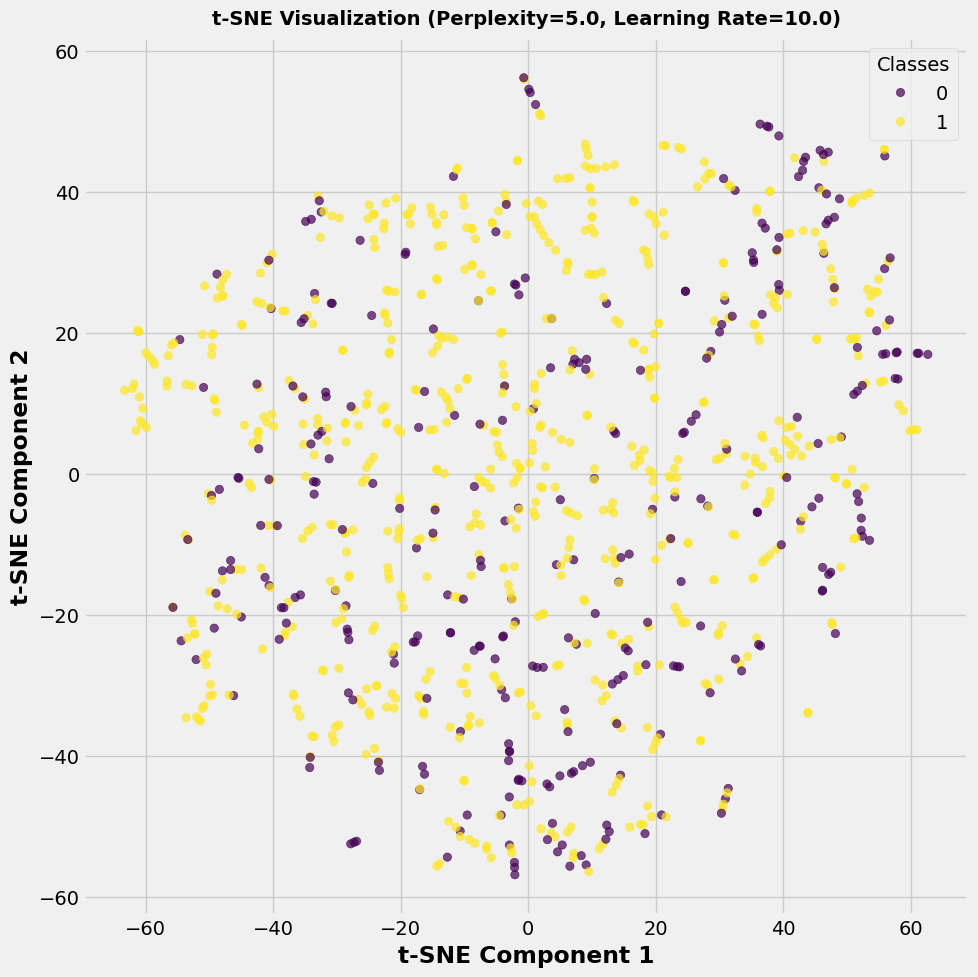

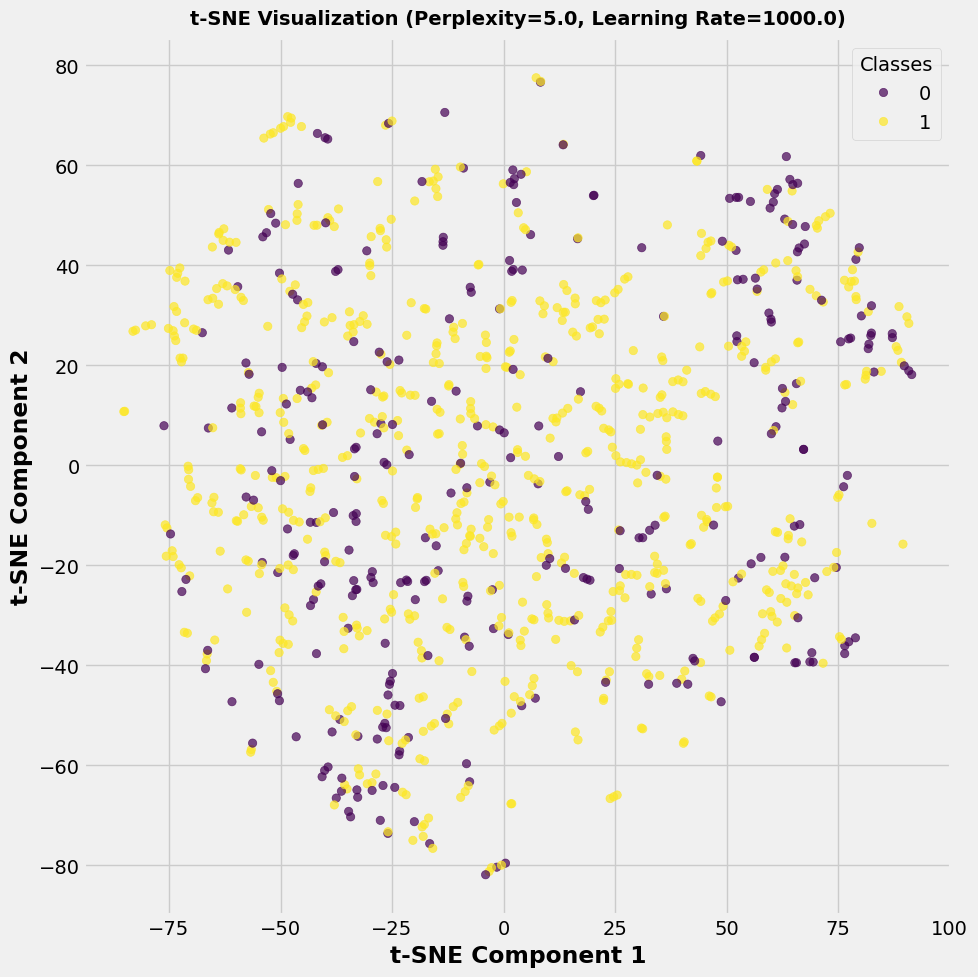

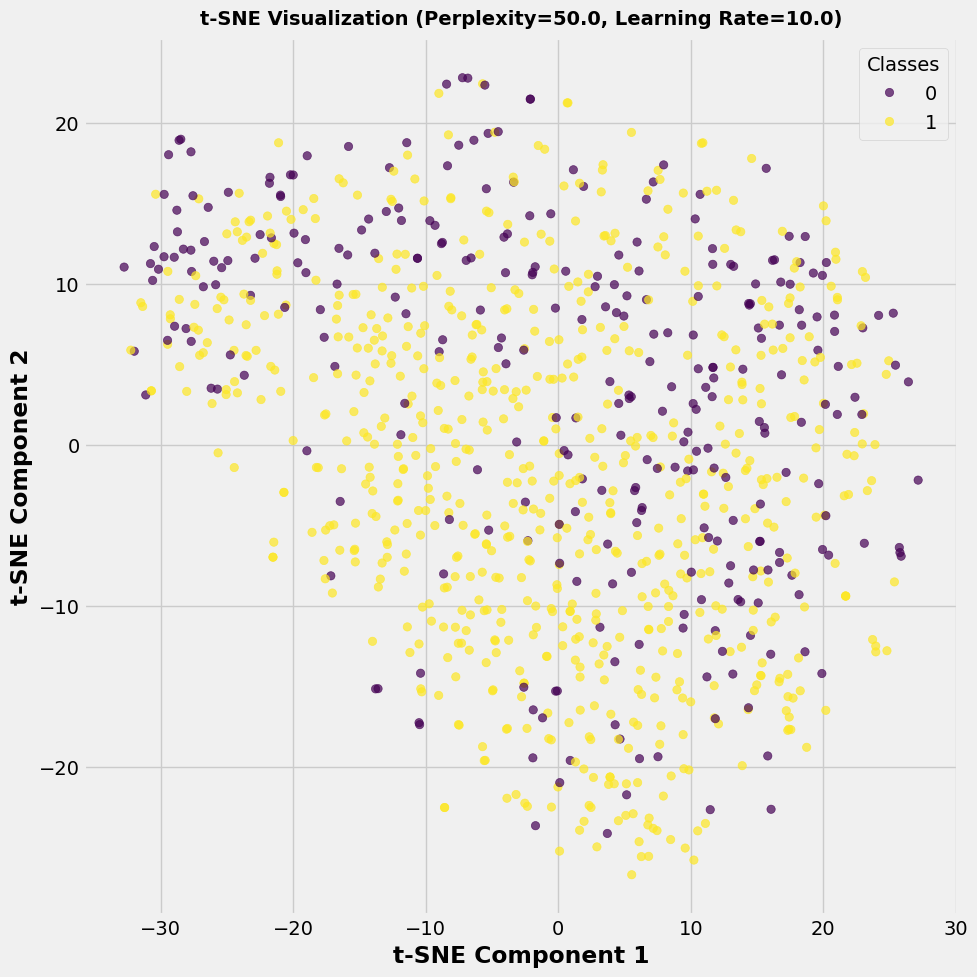

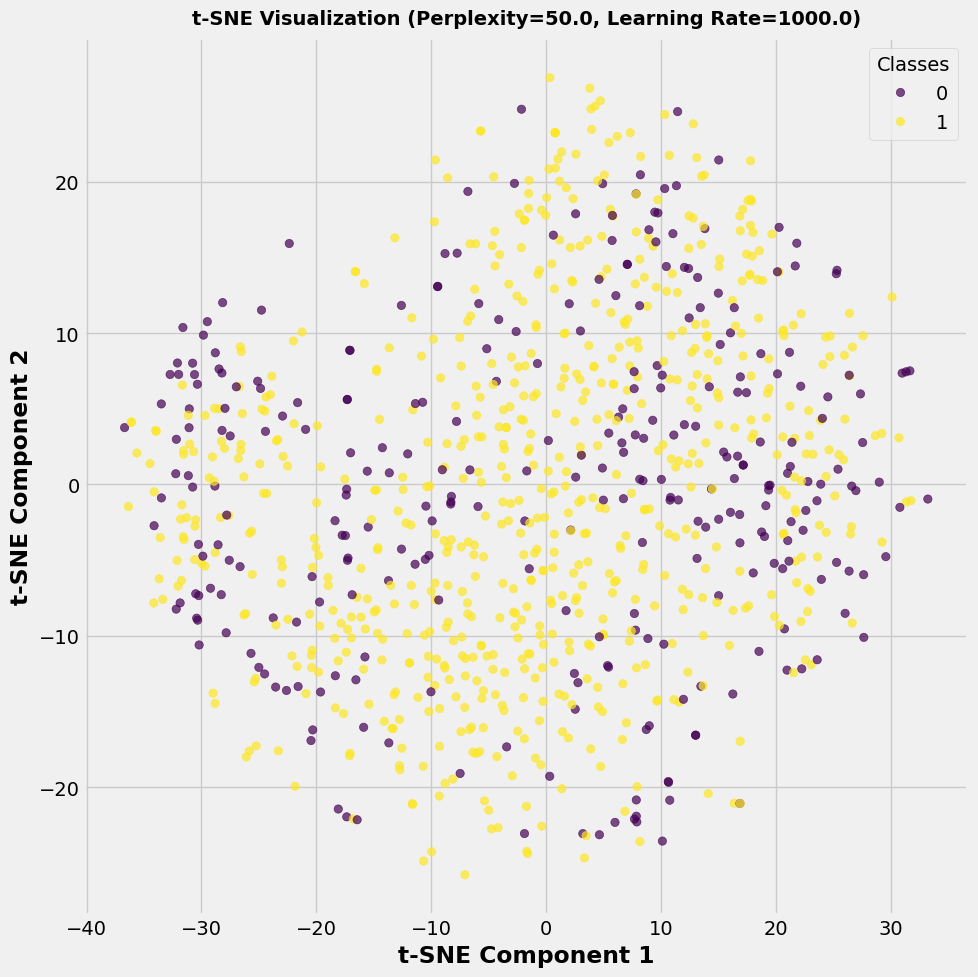

In [123]:
#### I Apply t-SNE for dimensionality reduction
# I define perplexities and learning rates
perplexities = np.linspace(5, 50, 2)
learning_rate = np.linspace(10, 1000, 2)

# Iterate over all combinations of perplexity and learning rate
for i, perplexity in enumerate(perplexities, 1):
    for lr in learning_rate:
        # Create a t-SNE model
        tsne = TSNE(
            n_components=2, 
            perplexity=perplexity, 
            random_state=42, 
            learning_rate = lr)
        X_tsne = tsne.fit_transform(df_scaled[features])

        # Plotting
        # X_tsne = X_tsne + 0.01 * np.random.randn(*X_tsne.shape)
        plt.figure(figsize=(10, 10))
        scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7, c=df_scaled['good_bad'], label=df_scaled['good_bad'])
                
        plt.title(f't-SNE Visualization (Perplexity={perplexity}, Learning Rate={lr})')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        handles, labels = scatter.legend_elements(prop="colors")
        plt.legend(handles, labels, loc="best", title="Classes")
        plt.show()  # Show the plot


## 2.2 Unsupervised Data Analysis
---
### For practical reason we move the  Unsupervised Data Analysis [to another file](./Adversial%20Attack%20Unsupervised%20Data%20Analyis.ipynb)

#     3 Supervised Data Analysis
---

### For practical reason we move the workflow that we made for arriving at use SMOTE for the Supervised Data Analysis [to another file](./Adversarial%20Attack%20Supervised%20Data%20Analysis.ipynb)

### 3.1 Classifier Selection
We choose from various classifiers, notably:
- Decision Tree classifier
- Gaussian Naive Bayes classifier
- K-Nearest Neighbors classifier
- Support Vector Machines classifier
- Logistic regressor
- Neural Networks 

### Neural Network

## Training NN, NO PCA NO SMOTE

In [124]:
class Model_classification_multi(nn.Module): 
    def __init__(self, in_features, out_features, hidden_1, hidden_2, hidden_3):
        super(Model_classification_multi, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, hidden_3),
            nn.ReLU(),
            nn.Linear(hidden_3, out_features)
        )
    
    def forward(self, x):
        return self.layers(x)  # Remove softmax, leaving layer sequence

# Rest of the code remains the same
class PyTorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, in_features, hidden_1, hidden_2, hidden_3, lr=0.001, epochs=50, batch_size=64):
        self.in_features = in_features
        self.hidden_1 = hidden_1
        self.hidden_2 = hidden_2
        self.hidden_3 = hidden_3
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = Model_classification_multi(in_features, 2, hidden_1, hidden_2, hidden_3)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()
        self.history = {'loss': [], 'val_loss': []}
        self.classes_ = None  # Initialize the attribute for classes

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
        
        self.classes_ = np.unique(y)  # Set the classes_ attribute
        
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        # Separate validation set
        X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, train_size=0.85, random_state=15)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.long)

        for epoch in range(self.epochs):
            self.model.train()
            epoch_loss = 0
            for batch_X, batch_y in loader:
                y_pred = self.model(batch_X)
                loss = self.loss_fn(y_pred, batch_y)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            
            # Save training loss
            self.history['loss'].append(epoch_loss / len(loader))
            
            # Validation loss
            self.model.eval()
            with torch.no_grad():
                y_val_pred = self.model(X_val_tensor)
                val_loss = self.loss_fn(y_val_pred, y_val_tensor)
                self.history['val_loss'].append(val_loss.item())
        
        return self

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
            
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            y_pred = self.model(X_tensor)
        return torch.argmax(y_pred, dim=1).numpy()

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
            
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            y_pred = self.model(X_tensor)
        return y_pred.numpy()

    def plot_validation_curve(self):
        x = list(range(len(self.history['loss'])))
        plt.plot(x, self.history['loss'], label='Training loss')
        plt.plot(x, self.history['val_loss'], label='Validation loss')
        plt.xlabel('Epochs')
        plt.ylabel('Cross-Entropy Loss')
        plt.title('Validation Curve')
        plt.legend()
        plt.show()

## Hyperparameter Tuning - NN

In [125]:
# Grid definition for hyperparameter search
param_grid = {
    'hidden_1': [64, 128],
    'hidden_2': [32, 64],
    'hidden_3': [16, 32],
    'lr': [0.001, 0.0001],
    'batch_size': [32, 64],
    'epochs': [50, 100]
}

In [126]:
# Implement StratifiedKFold to preserve class distribution during lookup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=15)

# PyTorch Classifier Model Initialization
model = PyTorchClassifier(in_features=X.shape[1], hidden_1=64, hidden_2=32, hidden_3=16)

# Implementing Hyperparameter Search with GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

# Better hyperparameters
print(f"Best hyperparameters found: {grid_search.best_params_}") 

Best hyperparameters found: {'batch_size': 64, 'epochs': 50, 'hidden_1': 64, 'hidden_2': 64, 'hidden_3': 16, 'lr': 0.001}


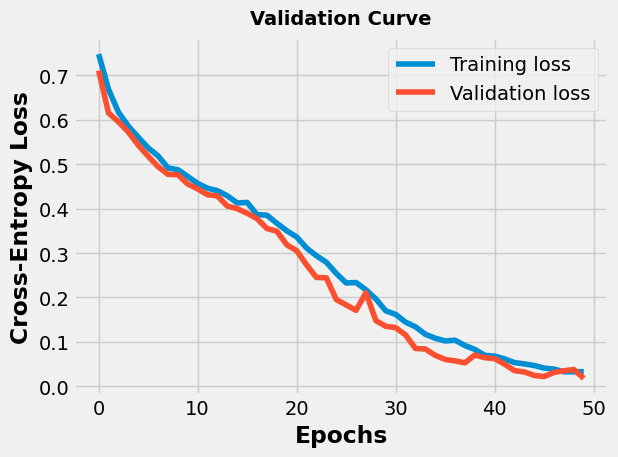

In [127]:
# Using the model with the best hyperparameters for evaluation
best_model = grid_search.best_estimator_
# Validation curve plot
best_model.plot_validation_curve()

### 3.2 Cross-Validation

#### Here we consider non NN classifiers

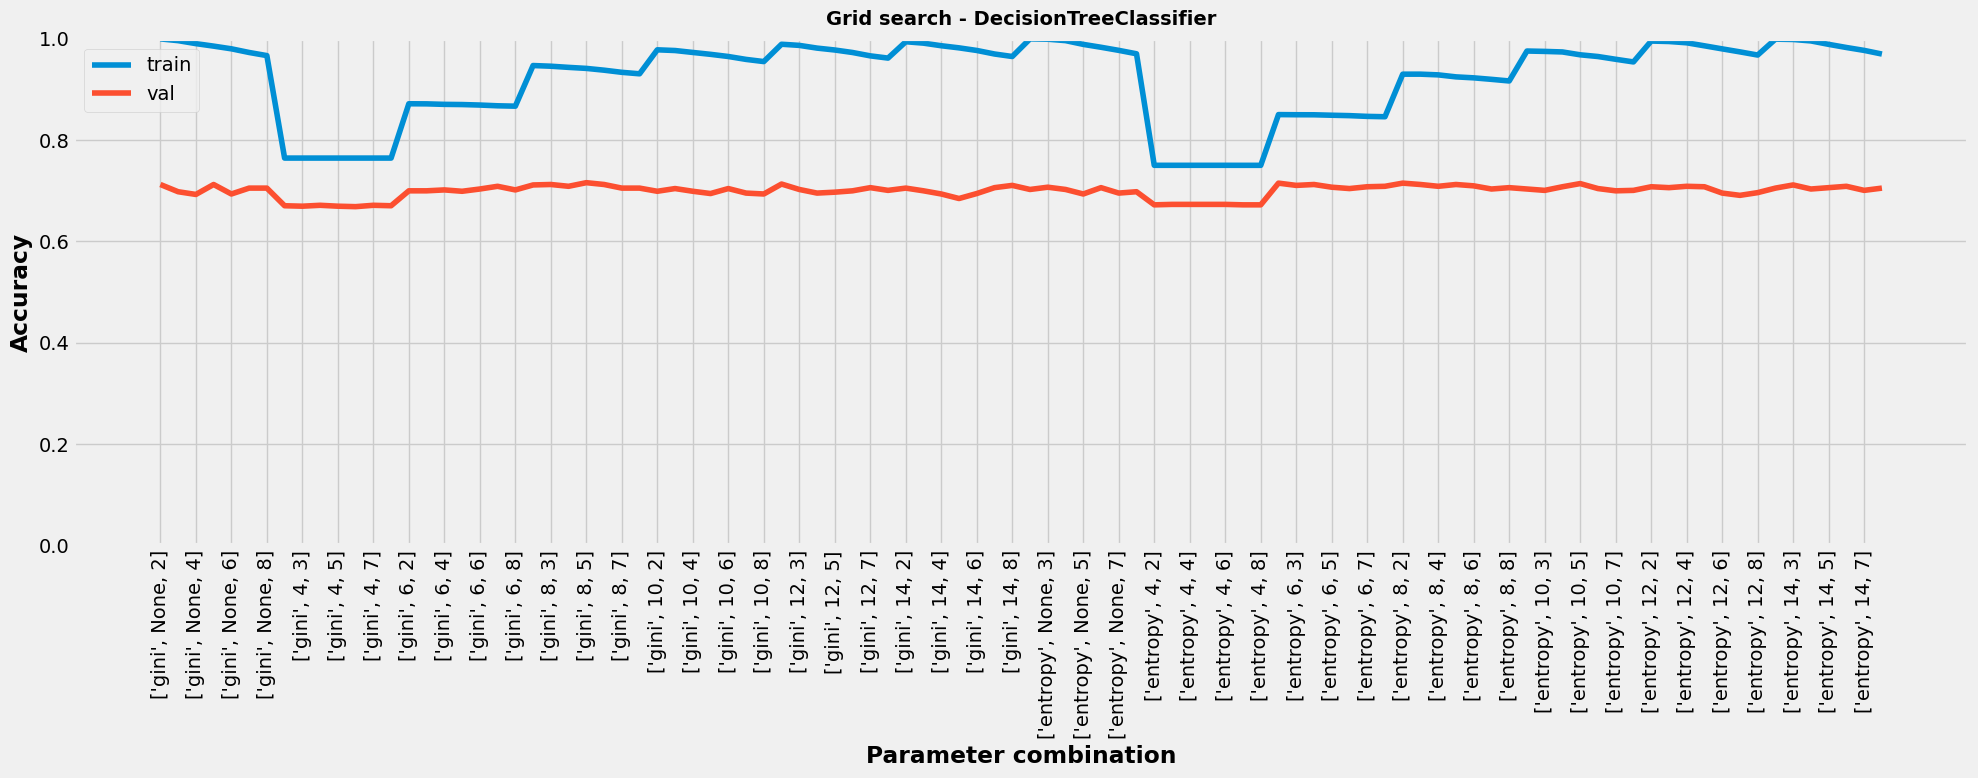

Best Score for DecisionTreeClassifier: 0.7160714285714286
Best Parameters  {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 5} 



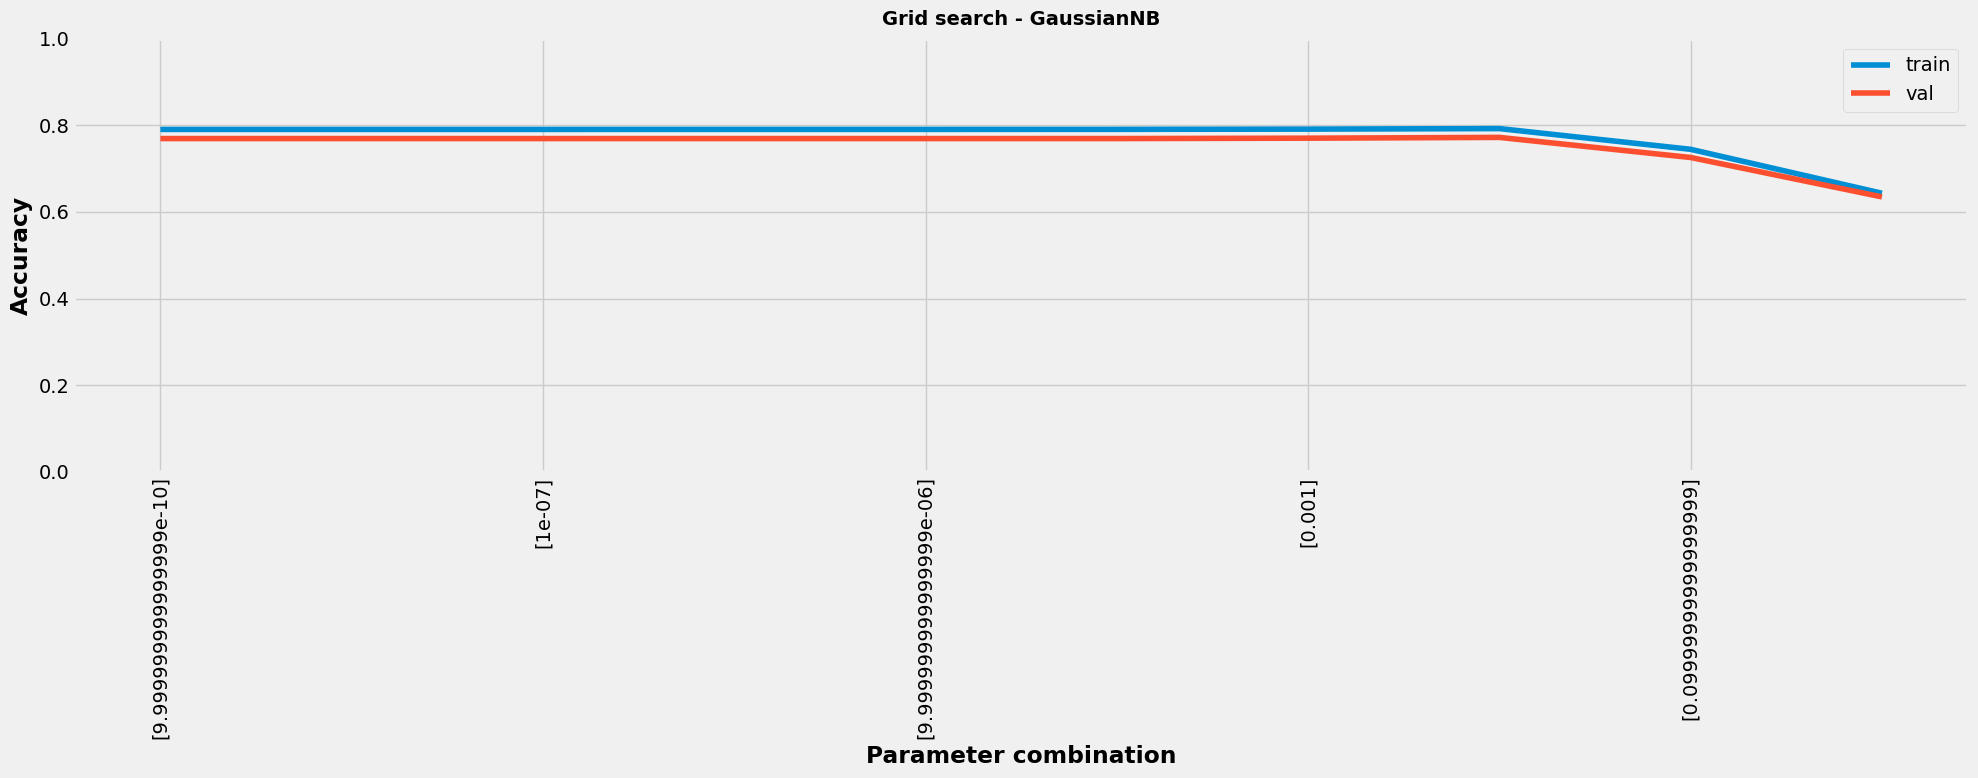

Best Score for GaussianNB: 0.7723214285714285
Best Parameters  {'var_smoothing': 0.01} 



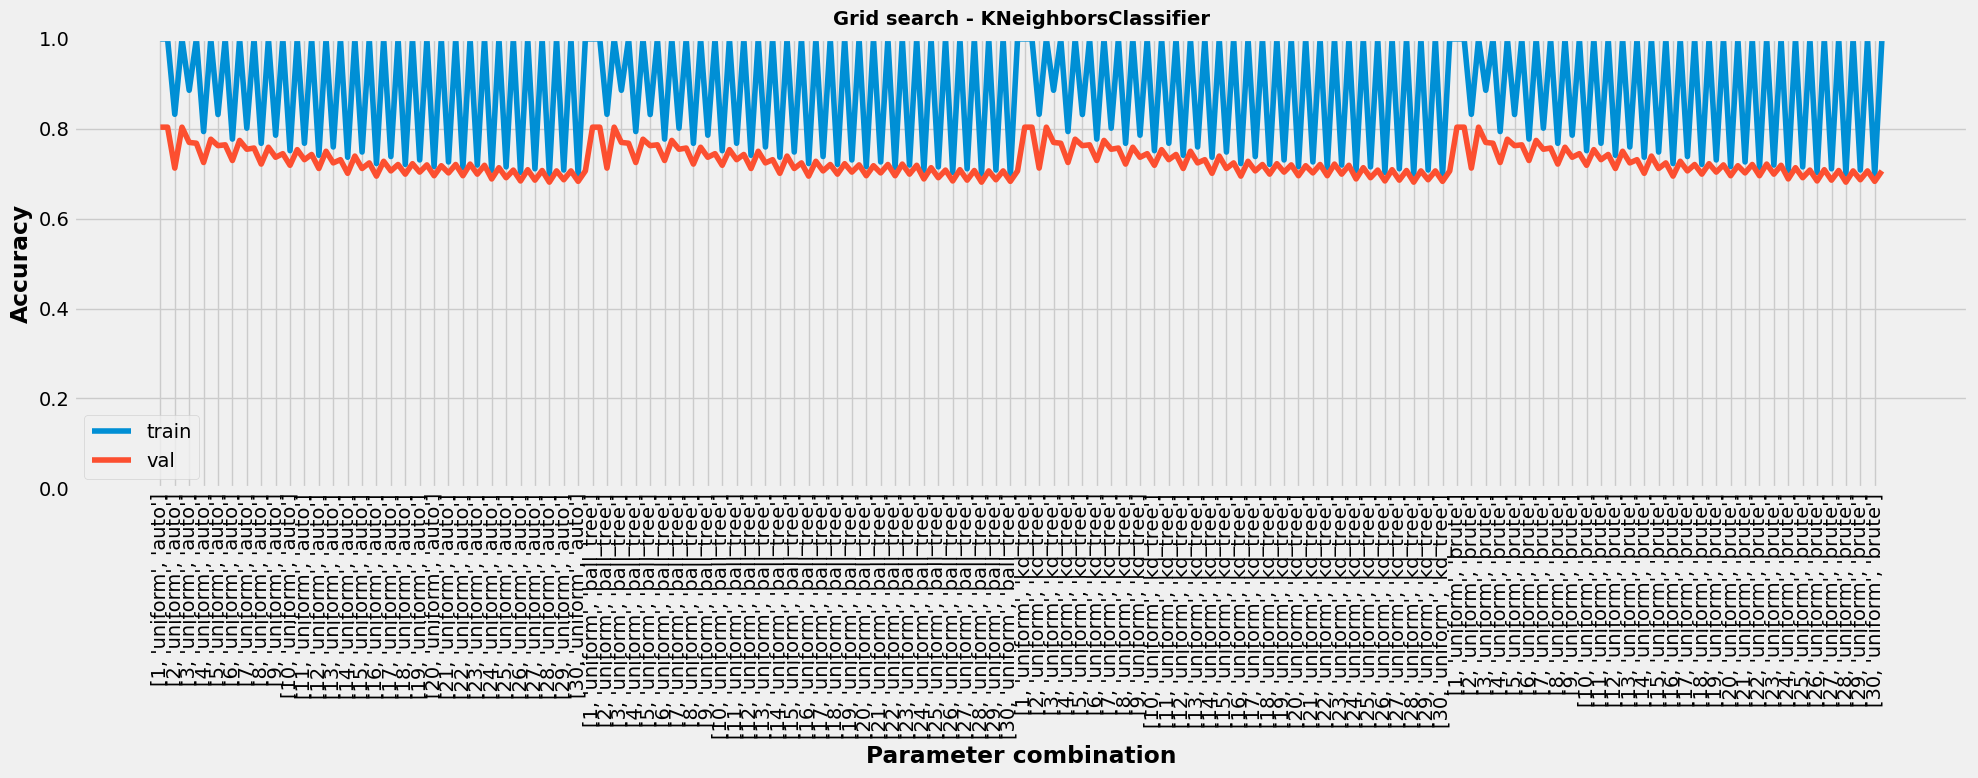

Best Score for KNeighborsClassifier: 0.8035714285714285
Best Parameters  {'algorithm': 'auto', 'n_neighbors': 1, 'weights': 'uniform'} 



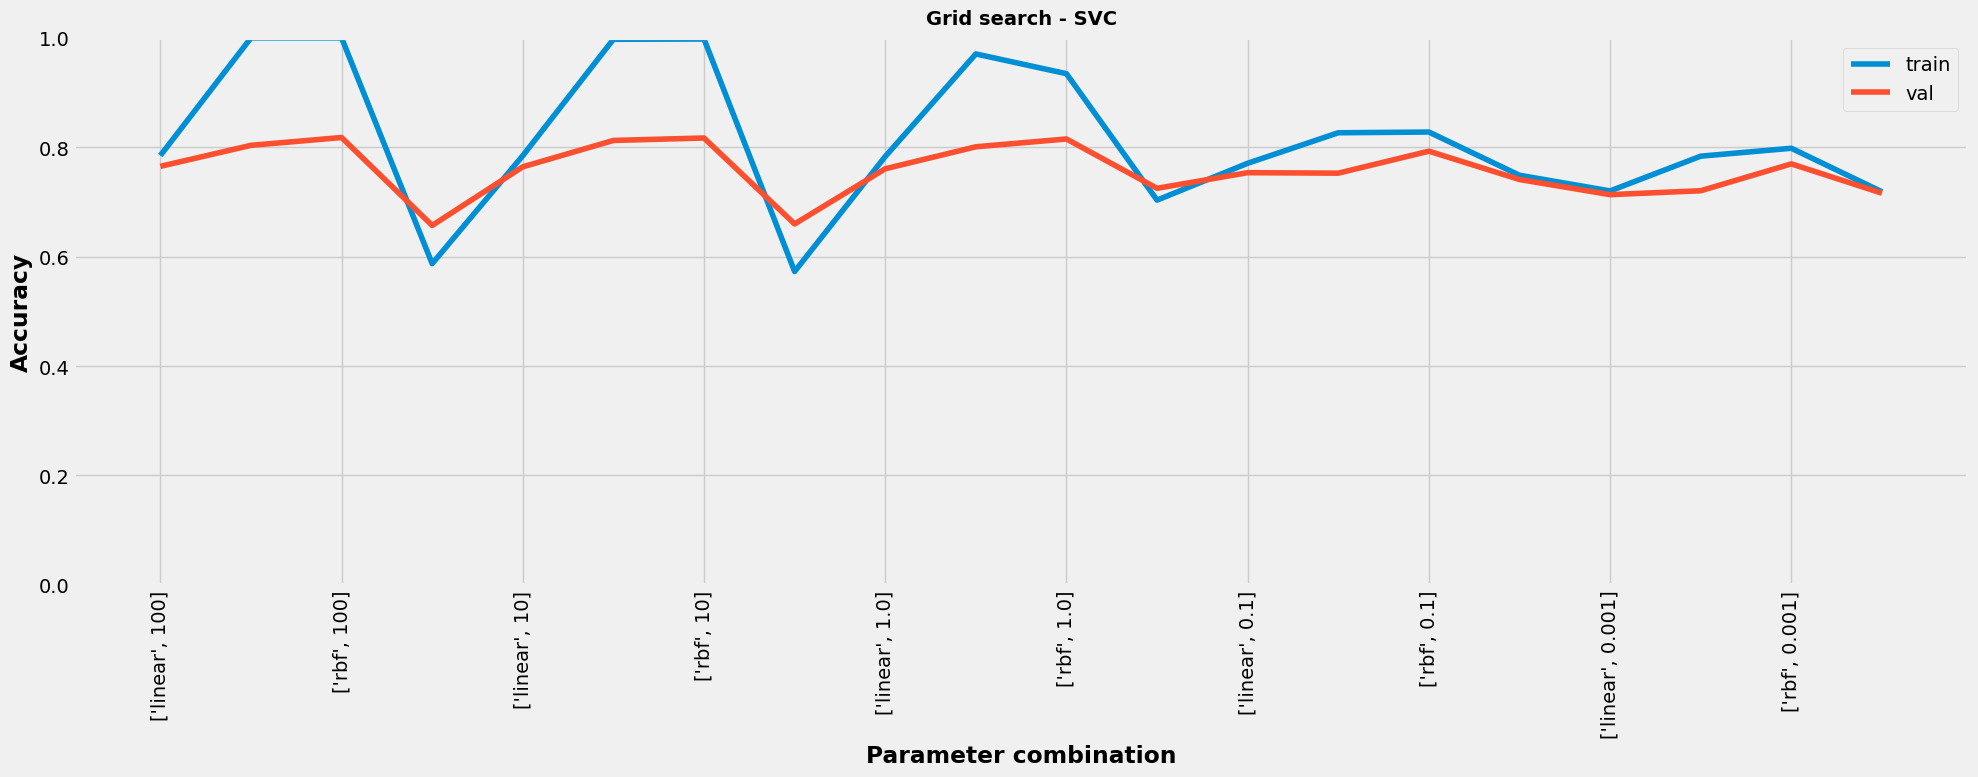

Best Score for SVC: 0.8178571428571428
Best Parameters  {'C': 100, 'kernel': 'rbf'} 



/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWar

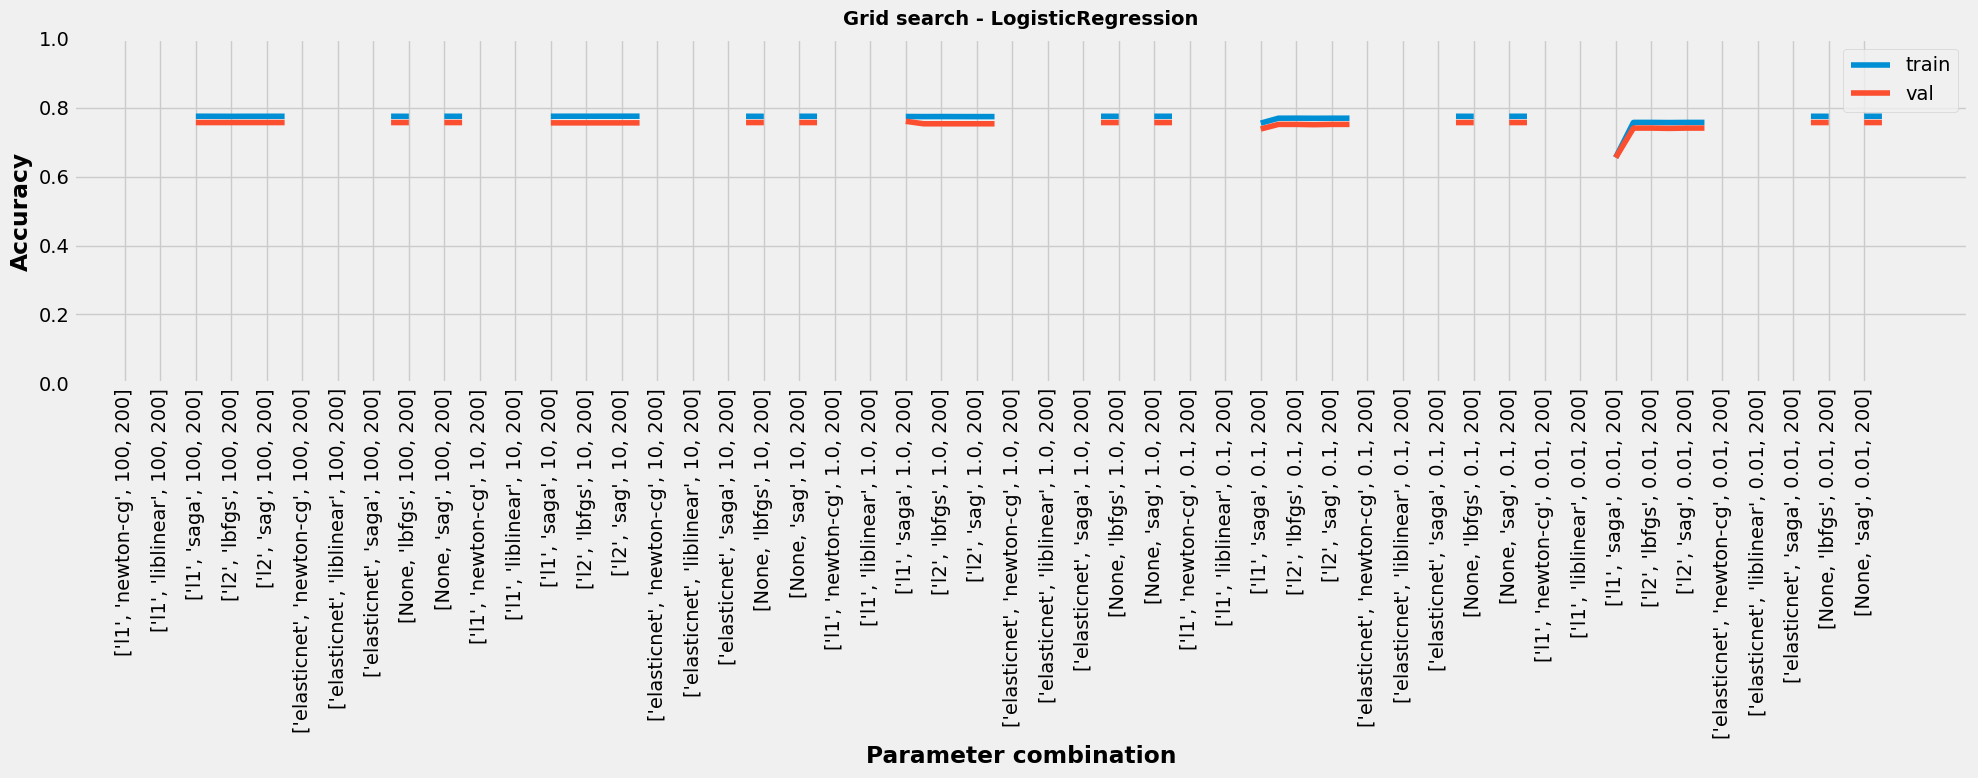

Best Score for LogisticRegression: 0.7607142857142856
Best Parameters  {'C': 1.0, 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'} 


Best Classifier: SVC
Best Score:  0.8178571428571428


In [128]:
best = 0
DT_parameters = {"criterion":['gini', 'entropy'], 'max_depth':[None, 4, 6, 8, 10, 12, 14], 'min_samples_split':[2, 3, 4, 5, 6, 7, 8]}
GNB_parameters = {"var_smoothing": (np.logspace(-9,0,10))}
KNN_parameters = {"n_neighbors": range(1,31), "weights": ['uniform','distance'], "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute']}
SVM_parameters = {"kernel": ['linear', 'poly', 'rbf', 'sigmoid'], "C": [100, 10, 1.0, 0.1, 0.001]}
LR_parameters = {"penalty": ['l1', 'l2', 'elasticnet', None], "solver": ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'], "C": [100, 10, 1.0, 0.1, 0.01], "max_iter": [200]}
classifiers = [{"classifier": DecisionTreeClassifier, "parameters": DT_parameters}, {"classifier": GaussianNB, "parameters": GNB_parameters},
               {"classifier": KNeighborsClassifier, "parameters": KNN_parameters}, {"classifier": svm.SVC, "parameters": SVM_parameters}, 
               {"classifier": LogisticRegression, "parameters": LR_parameters}]

for classifier in classifiers:
    clf = GridSearchCV(classifier["classifier"](), classifier["parameters"], cv = StratifiedKFold(n_splits=20), scoring = 'accuracy', n_jobs=10, return_train_score=True)
    clf.fit(X_PCA, y_res)

    best_param_set = clf.best_params_
    
    param_names = classifier["parameters"].keys()
    x_label_ticks = [str([param[name] for name in param_names]) for param in clf.cv_results_['params']]

    plt.figure(figsize=(20,8))
    plt.plot(x_label_ticks, clf.cv_results_['mean_train_score'], label='train')
    plt.plot(x_label_ticks, clf.cv_results_['mean_test_score'], label='val')
    plt.title("Grid search - " + str(classifier["classifier"]()).replace("()",""))
    plt.xlabel('Parameter combination')
    plt.ylabel("Accuracy")
    plt.xticks(range(0, len(x_label_ticks), 2), rotation=90)  # Added a step because some plots would be unreadable
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

    if (clf.best_score_ > best):
        best = clf.best_score_
        best_clf = clf
        best_clf_param = list(classifier["parameters"].keys())
        best_clf_name = classifier["classifier"]
        best_clf_score = clf.best_score_
    print("Best Score for " + str(classifier["classifier"]()).replace("()","") + ":", clf.best_score_)
    print("Best Parameters ", clf.best_params_,"\n")

print("\nBest Classifier: " + str(best_clf_name()).replace("()",""))
print("Best Score: ",best_clf_score)

['kernel', 'C']


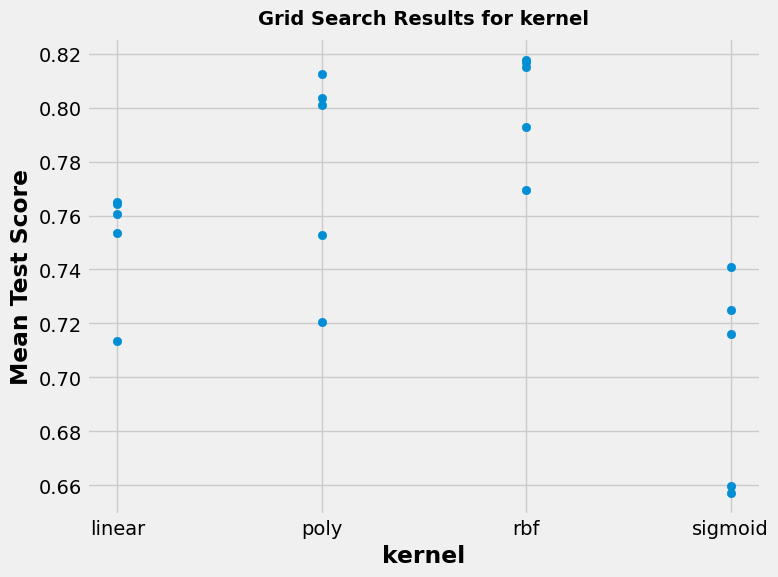

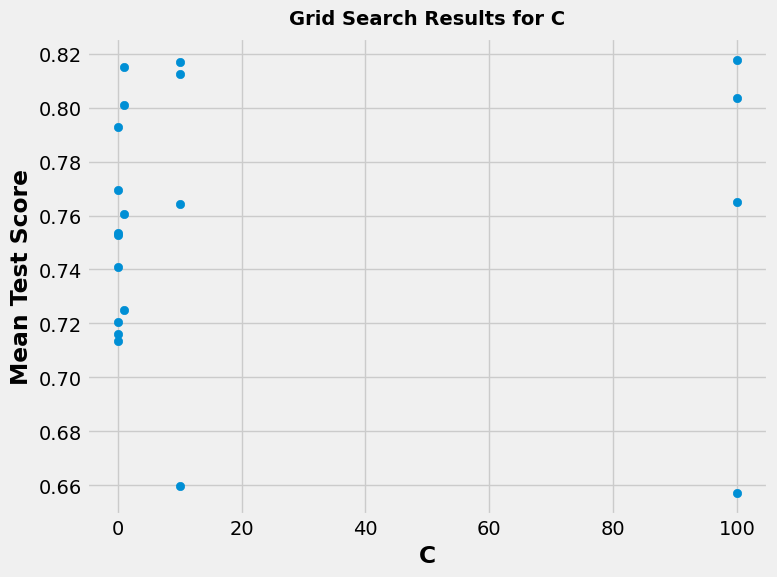

In [129]:
def plot_grid_search(cv_results, param_name, scoring=None):
    if scoring is None:
        scoring = list(cv_results['mean_test_score'])[0]
        
    # Extract the mean test scores and the parameter values
    mean_test_scores = cv_results['mean_test_score']
    param_values = cv_results['param_' + param_name].data

    # Sort the parameter values and corresponding test scores
    sorted_indices = np.argsort(param_values)
    sorted_param_values = np.array(param_values)[sorted_indices]
    sorted_mean_test_scores = np.array(mean_test_scores)[sorted_indices]

    plt.figure(figsize=(8, 6))
    plt.scatter(sorted_param_values, sorted_mean_test_scores, marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Mean Test Score')
    plt.title(f'Grid Search Results for {param_name}')
    plt.grid(True)
    plt.show()
    
print(best_clf_param)
for i in range(len(best_clf_param)):
    plot_grid_search(best_clf.cv_results_, best_clf_param[i])


## 3.3 Classifier Evaluation

#### Non-NN Classifier

Using classifier : SVC()
              precision    recall  f1-score   support

           0       0.51      0.50      0.50        60
           1       0.79      0.79      0.79       140

    accuracy                           0.70       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.70      0.70      0.70       200



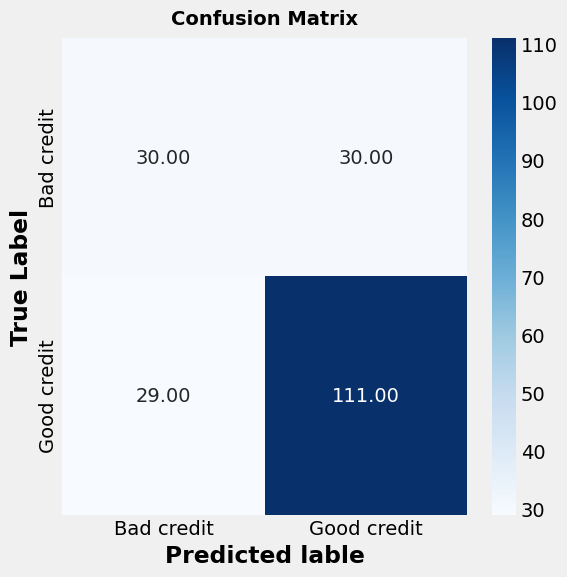

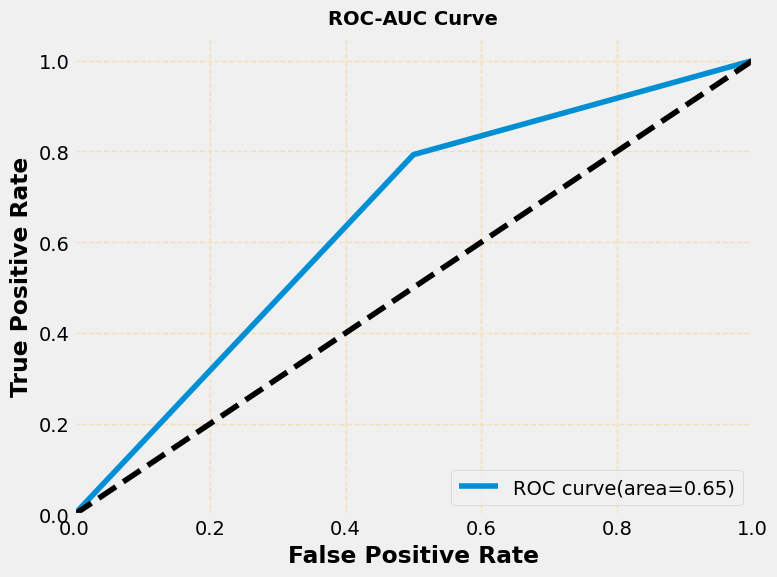

(array([0. , 0.5, 1. ]),
 array([0.        , 0.79285714, 1.        ]),
 array([inf,  1.,  0.]))

In [130]:
#### From the Cross-Validation analysis I take the best classifier and test it over the Test set
print(f'Using classifier : {best_clf_name()}')
clf_final = best_clf_name(**best_clf.best_params_)
clf_final.fit(X_PCA, y_res)
y_pred = clf_final.predict(X_test_PCA)

#### Classification report
print(classification_report(y_test, y_pred))

#### Get the confusion matrix of test set
confusion_matri(y_test, y_pred)

#### ROC Curve
draw_roc(y_test, y_pred)

#### Neural Network

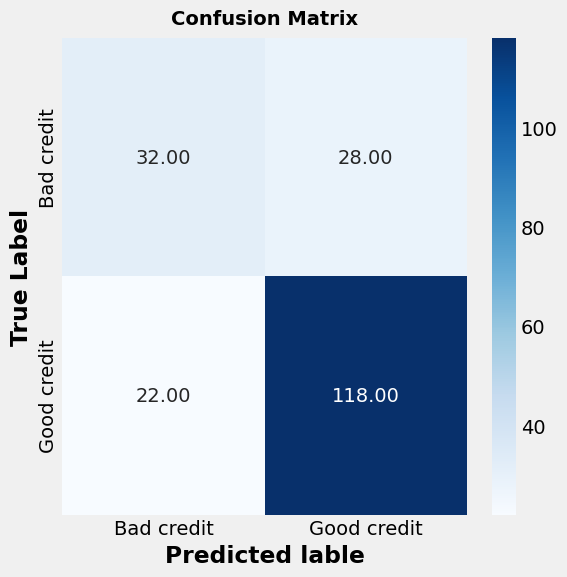

[[ 32  28]
 [ 22 118]]
              precision    recall  f1-score   support

           0       0.59      0.53      0.56        60
           1       0.81      0.84      0.83       140

    accuracy                           0.75       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.74      0.75      0.75       200

Accuracy: 0.7500


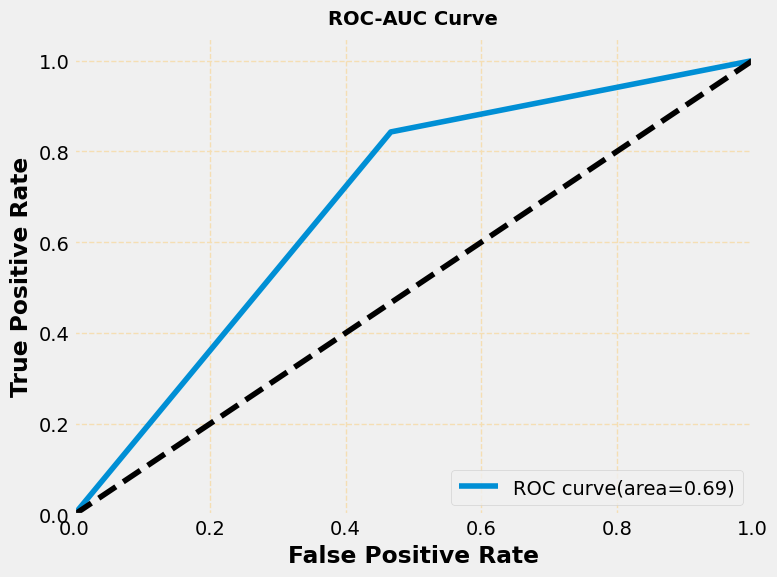

AUC score: 0.6880952380952381


In [131]:
y_pred = best_model.predict(X_test)


# Confusion Matrix and Classification Report
confusion_matri(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {final_accuracy:.4f}")


#### ROC Curve
draw_roc(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)
print(f"AUC score: {auc}")

# 4 Adversarial Attack #

### 4.1 Adding Random Noise

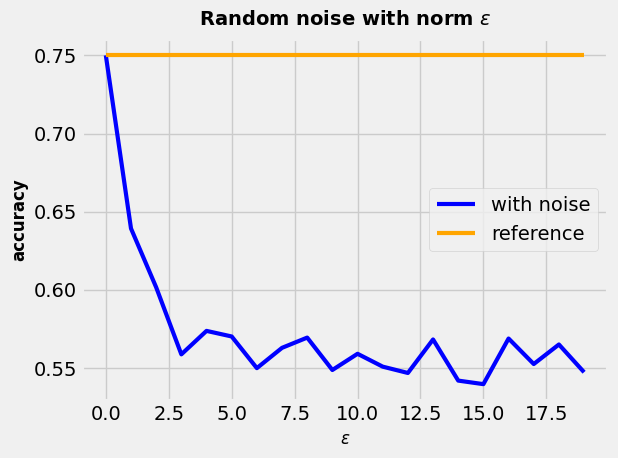

In [132]:
# Funzione per la valutazione del modello
def evaluate_best(X, y, model, only_score=False, scoring=balanced_accuracy_score):
    y_pred = model.predict(X)
    if only_score:
        return scoring(y, y_pred)
    else:
        print(confusion_matrix(y, y_pred))
        print(classification_report(y, y_pred))
        return scoring(y, y_pred)

# Ciclo di test del rumore
eps_x = np.arange(0, 20, 1)  # Iniziare da 0 per includere il caso senza rumore
eps_acc = [final_accuracy]  # Include the final accuracy at eps = 0

noisyy = y_test.copy()

for eps in eps_x[1:]:  # Skip the first element (0) since we already have that accuracy
    acc_vs = []
    for _ in range(10):
        noise = np.clip(np.random.normal(0, eps / np.sqrt(X_test.shape[1]), X_test.shape), -0.5, 0.5)
        noisyX = X_test + noise
        acc = evaluate_best(noisyX, noisyy, model=best_model, only_score=True, scoring=balanced_accuracy_score)
        acc_vs.append(acc)
    if eps in [0.5, 19.5]:  # Show confusion matrix at these points
        evaluate_best(noisyX, noisyy, model=best_model, scoring=balanced_accuracy_score)
    eps_acc.append(np.mean(acc_vs))

# Plot dei risultati
plt.plot(eps_x, eps_acc, color='blue', label='with noise', linewidth=3)
plt.plot(eps_x, [final_accuracy] * len(eps_x), color='orange', label='reference', linewidth=3)
plt.title('Random noise with norm $\\epsilon$', fontsize=14, fontweight='bold')
plt.xlabel('$\\epsilon$', fontsize=12)
plt.ylabel('accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Feature specific noise

In [142]:
def add_noise(data, epsilon):
    # display(data)
    noise = np.clip(np.random.normal(0, epsilon / np.sqrt(data.shape), size = data.shape), -0.5, 0.5)
    noisy_data = data + noise

    return noisy_data


epsilon_max = 11
step = 0.5

# Calculate accuracy with noise added
accuracy_epsilon = []
accuracy_noise_norm = []
epsilons = np.arange(1, epsilon_max, step)

for epsilon in epsilons:
    accuracy = {}
    print("Epsilon: ", epsilon)
    print("---------------------------------------------------------------------------------------------------------------------------------------------------")
    
    # Adding random noise to numerical features
    for i_column in features:
        X_test_noised = X_test.copy() 
        column = add_noise(X_test[i_column], epsilon)
        X_test_noised[i_column] = column
        accuracy[i_column] = evaluate_best(X_test_noised, y_test, model=best_model,only_score= True ,scoring=balanced_accuracy_score)
    accuracy_epsilon.append(accuracy)

    values=[]
    for value in accuracy.values():
        values.append(value)

    ## I take the minimum value regardin the accuracy aspect, with the corrispective name
    min_value = min(values)
    min_key = values.index(min_value)
    min_key = list(accuracy.keys())[min_key]
    accuracy_noise_norm.append({'column': min_key, 'value': min_value})
    print("Min Accuracy: ", min(values), "attribute: ", min_key)


num_plots = len(accuracy_epsilon)  # Number of different noise levels or columns

fig, axs = plt.subplots(num_plots, 1, figsize=(10, 8 * num_plots), tight_layout=True)
fig.suptitle('Changes in Metrics with Noised Columns', fontsize=16)
colors = plt.cm.viridis(np.linspace(0, 1, len(epsilons)))

for i, accuracy in enumerate(accuracy_epsilon):
    keys = list(accuracy.keys())
    values = list(accuracy.values())

    axs[i].plot(keys, values, linestyle='solid', marker='o')
    axs[i].plot(keys, [final_accuracy] * len(keys), color='orange', label='reference')
    axs[i].set_title(f'Epsilon: {epsilons[i]}')
    axs[i].set_xlabel('Changed Column')
    axs[i].set_ylabel('Balanced Accuracy')
    axs[i].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for readability
    axs[i].legend()

Epsilon:  1.0
---------------------------------------------------------------------------------------------------------------------------------------------------


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

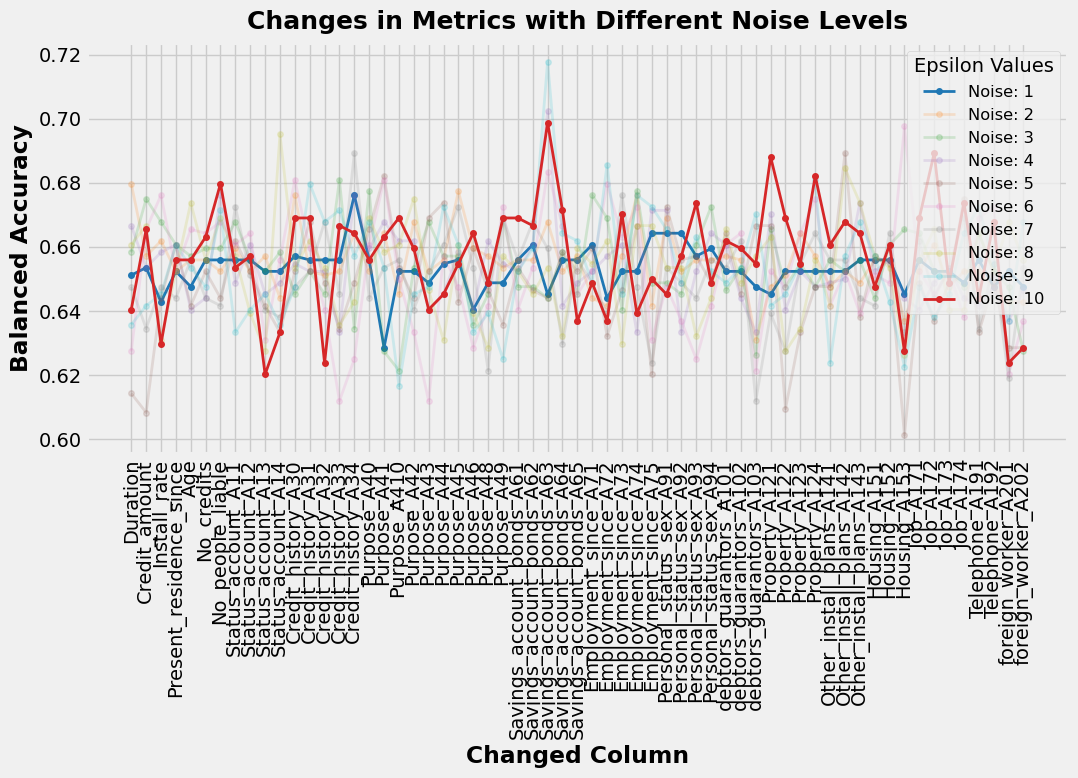

In [84]:
###############################################################################
## PLOTTING ALL OF THEM TOGETHER - Just to Visualize how they are distributed##
###############################################################################
epsilons = np.arange(1, 11, 1)

colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",   # Teal
    "#d62728"  # Red
]

opacity = 0.17
alpha = [1,opacity, opacity, opacity, opacity, opacity, opacity, opacity, opacity, 1]

plt.figure(figsize=(11, 8))
plt.title('Changes in Metrics with Different Noise Levels', fontsize=18)
plt.xlabel('Changed Column')
plt.ylabel('Balanced Accuracy')

for i, (accuracy, color, alpha) in enumerate(zip(accuracy_epsilon, colors, alpha)):
    keys = list(accuracy.keys())
    values = list(accuracy.values())
    plt.plot(keys, values, linestyle='solid', marker='o', markersize=4, linewidth=2, label='Noise: ' + str(epsilons[i]), color=color, alpha=alpha)
    

plt.xticks(list(accuracy.keys()), rotation=90)
plt.grid(True)
plt.legend(title='Epsilon Values', fontsize='small')


In [86]:
#################################################################################################################################
#Let's analyze the most vulnerable features using the list created before, containing the names and values of the columns 
#that received the lowest values of accuracy changing the noise-norm

## THIS IS THE CODE EXECUTED FOR PLOTTING THE MOST VULNERABLE FEATURE


# i = 0
# most_frequent = []
# accuracy_noColumn = []
# for noise_norm_threshold in np.arange(1, 21, 0.5):
#     print("\nMost Vulnerable with max Noise-Norm: ", noise_norm_threshold)
#     print("Accuracy\t", f"{accuracy_noise_norm[i]['column']}: {accuracy_noise_norm[i]['value']}")
#     accuracy_noColumn.append(accuracy_noise_norm[i]['value'])
#     most_frequent.append(accuracy_noise_norm[i]['column'])
#     i += 1

# # Count the occurrences among the lowest value of accuracy and precision and take the most_common, we will consider that value as the most vulnerable
# element_count = Counter(most_frequent)
# most_vulnerable_elements = element_count.most_common()
# print("The most vulnerable feature is: ", most_vulnerable_elements)



# # Extract the features and their corresponding counts
# most_vul_features = [item[0] for item in most_vulnerable_elements]
# most_vul_counts = [item[1] for item in most_vulnerable_elements]

# # Plotting the bar chart
# plt.figure(figsize=(10, 6))
# plt.bar(most_vul_features, most_vul_counts, color='skyblue')
# plt.xlabel('Features')
# plt.ylabel('Number of Occurrences')
# plt.title('Most Vulnerable Features Based on Frequency of Low Accuracy')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

## 4.3 Adversarial Attack using ART

In [141]:
# Define epsilon values to test
eps_values = np.linspace(0.0, 1.0, 22)

# Create a function to evaluate the attack
def evaluate_attack(attack, X_test, y_test, classifier, eps_values):
    accuracies = []
    for eps in eps_values:
        attack_instance = attack(estimator=classifier, eps=eps, eps_step=0.01, max_iter=10)  
        X_test_adv = attack_instance.generate(x=X_test)
        
        # Test accuracy on adversarial samples
        predictions_adv = classifier.predict(X_test_adv)
        predictions_adv_binary = np.where(predictions_adv[:, 1] > 0.5, 1, 0)
        accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
        accuracies.append(accuracy_adv)

    accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
    print(f"Adversarial test data accuracy: {accuracy_adv * 100:.2f}%")
    print(classification_report(y_test, predictions_adv_binary))

    
    confusion_matri(y_test, predictions_adv_binary)

    #### ROC Curve
    draw_roc(y_test, predictions_adv_binary)
    auc = roc_auc_score(y_test, predictions_adv_binary)
    print(f"AUC score: {auc}") 
    
    return accuracies

# Convert test data to float32 and NumPy arrays
X_test = np.array(X_test).astype(np.float32)
y_test = np.array(y_test).astype(np.int64)

# Create a function to wrap the model
def create_classifier(model, loss_fn, optimizer, input_shape, nb_classes, clip_values=(0, 1)):
    return ARTClassifier(
        model=model,
        loss=loss_fn,
        optimizer=optimizer,
        input_shape=input_shape,
        nb_classes=nb_classes,
        clip_values=clip_values
    )

# Wrap the trained PyTorch model with ART PyTorch Classifier
classifier = create_classifier(best_model.model, best_model.loss_fn, best_model.optimizer, input_shape, nb_classes)

# Test the accuracy of the model on the original test samples
predictions = classifier.predict(X_test)
predictions_binary = np.where(predictions[:, 1] > 0.5, 1, 0)
accuracy = accuracy_score(y_test, predictions_binary)
print(f"Original test data accuracy: {accuracy * 100:.2f}%")

Original test data accuracy: 81.00%


### 4.3.1 Fast Gradient Sign Method (FGSM) Attack
The Fast Gradient Sign Method (FGSM) is one of the simplest and most effective adversarial perturbation attacks used to test the robustness of machine learning models, especially neural networks.The next Python code example demonstrates how to apply an evasion attack (Fast Gradient Sign Method, or FGSM) to a simple convolutional neural network (CNN) trained on the Fashion-MNIST dataset

Adversarial test data accuracy: 52.00%
              precision    recall  f1-score   support

           0       0.35      0.72      0.47        60
           1       0.78      0.44      0.56       140

    accuracy                           0.52       200
   macro avg       0.57      0.58      0.52       200
weighted avg       0.65      0.52      0.53       200



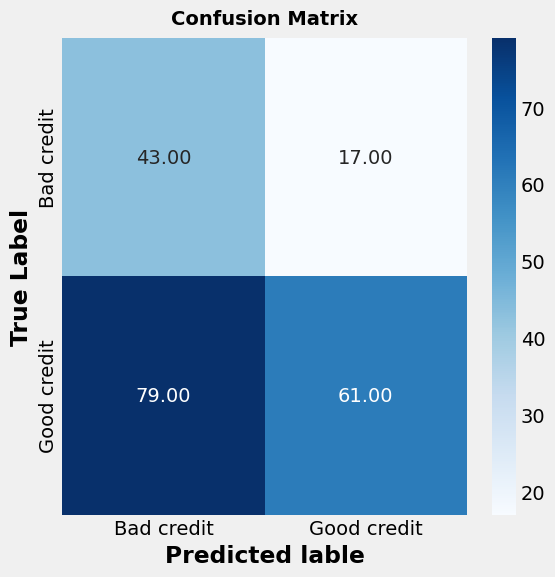

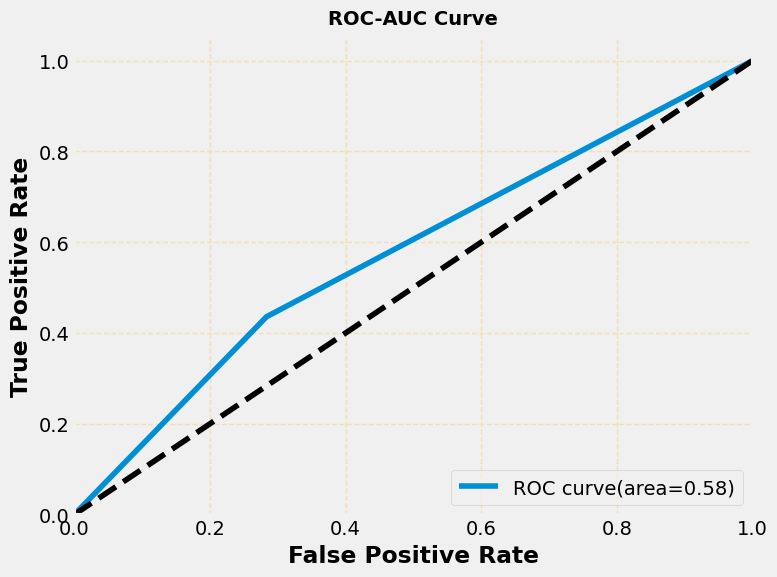

AUC score: 0.5761904761904761


In [134]:
# Esegui un attacco di evasione (FGSM) sui campioni di test
attack = FastGradientMethod(estimator=classifier, norm=2, eps=0.3)
X_test_adv = attack.generate(x=X_test)  # Genera esempi adversariali

# Testa l'accuratezza del modello sui campioni di test adversariali
predictions_adv = classifier.predict(X_test_adv)
predictions_adv_binary = np.where(predictions_adv[:, 1] > 0.5, 1, 0)  # Converti le probabilità in etichette binarie
accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
print(f"Adversarial test data accuracy: {accuracy_adv * 100:.2f}%")
print(classification_report(y_test, predictions_adv_binary))

# Confusion Matrix and Classification Report
confusion_matri(y_test, predictions_adv_binary)

#### ROC Curve
draw_roc(y_test, predictions_adv_binary)
auc = roc_auc_score(y_test, predictions_adv_binary)
print(f"AUC score: {auc}")

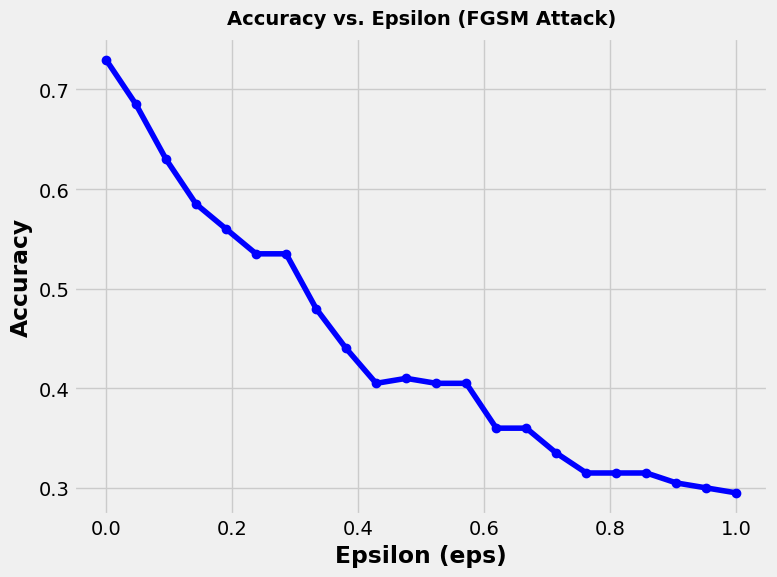

In [135]:
# Definire una gamma di valori di epsilon da testare
eps_values = np.linspace(0.0, 1.0, 22)  # Esempio: da 0 a 1.0 con 22 passi

accuracies = []

for eps in eps_values:
    # Esegui un attacco di evasione (FGSM) sui campioni di test
    attack = FastGradientMethod(estimator=classifier, norm=2, eps=eps)
    X_test_adv = attack.generate(x=X_test)
    
    # Testa l'accuratezza del modello sui campioni di test adversariali
    predictions_adv = classifier.predict(X_test_adv)
    predictions_adv_binary = np.where(predictions_adv[:, 1] > 0.5, 1, 0)  # Converti le probabilità in etichette binarie
    accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
    accuracies.append(accuracy_adv)

# Tracciare l'accuratezza in relazione a epsilon
plt.figure(figsize=(8, 6))
plt.plot(eps_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Epsilon (FGSM Attack)')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### 4.3.2 Basic Iterative Method (BIM) Attack
BIM is an iterative version of FGSM where multiple small perturbations are applied iteratively to craft adversarial examples.

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Adversarial test data accuracy: 37.00%
              precision    recall  f1-score   support

           0       0.27      0.63      0.38        60
           1       0.62      0.26      0.36       140

    accuracy                           0.37       200
   macro avg       0.44      0.45      0.37       200
weighted avg       0.51      0.37      0.37       200



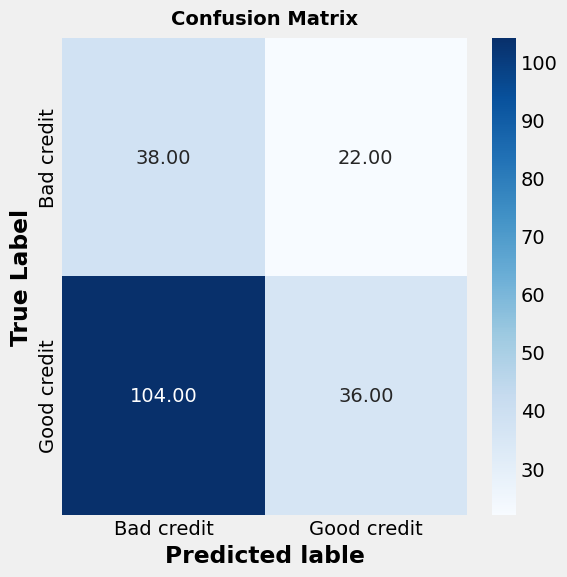

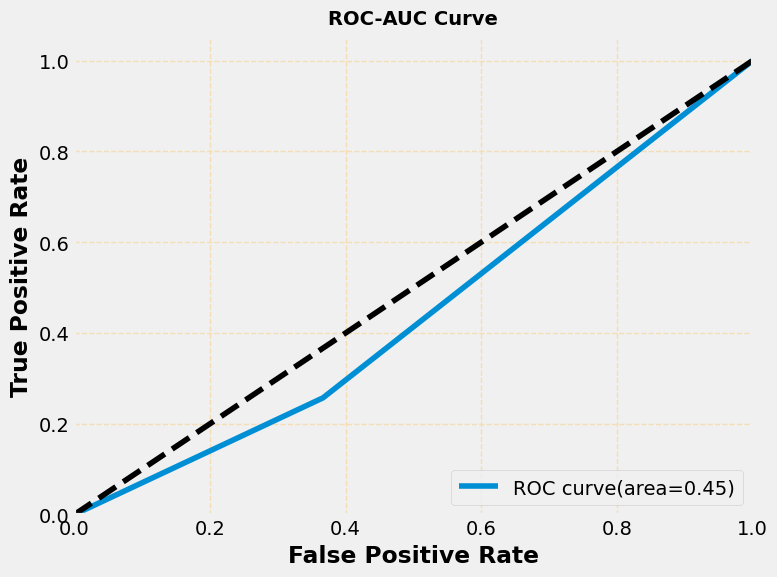

AUC score: 0.4452380952380952


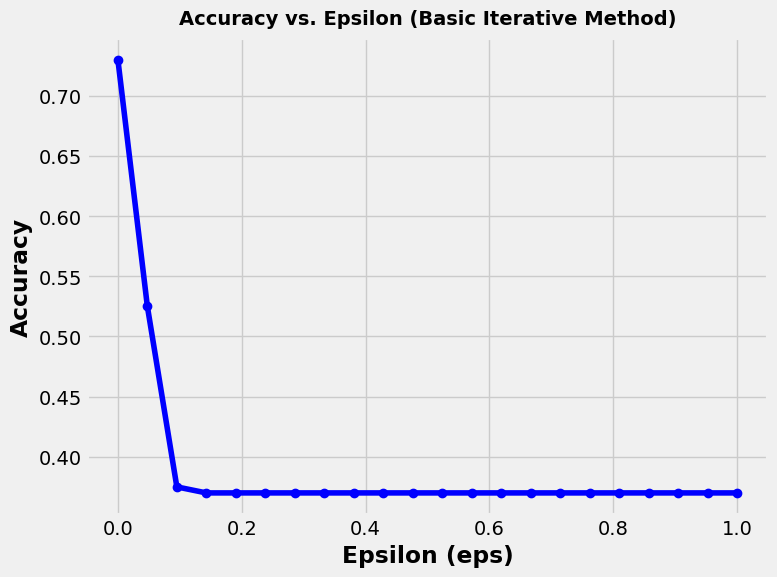

In [136]:
# Wrap the trained PyTorch model with ART PyTorch Classifier
classifier = create_classifier(best_model.model, best_model.loss_fn, best_model.optimizer, input_shape, nb_classes)

# Evaluate Basic Iterative Method attack
bim_attack = BasicIterativeMethod
accuracies_bim = evaluate_attack(bim_attack, X_test, y_test, classifier, eps_values)

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(eps_values, accuracies_bim, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Epsilon (Basic Iterative Method)')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### 4.3.3 Projected Gradient Descent (PGD) Attack
PGD is a more powerful variant of the iterative attack which also includes a projection step to ensure perturbations stay within a defined epsilon ball around the original data.

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Adversarial test data accuracy: 37.00%
              precision    recall  f1-score   support

           0       0.27      0.63      0.38        60
           1       0.62      0.26      0.36       140

    accuracy                           0.37       200
   macro avg       0.44      0.45      0.37       200
weighted avg       0.51      0.37      0.37       200



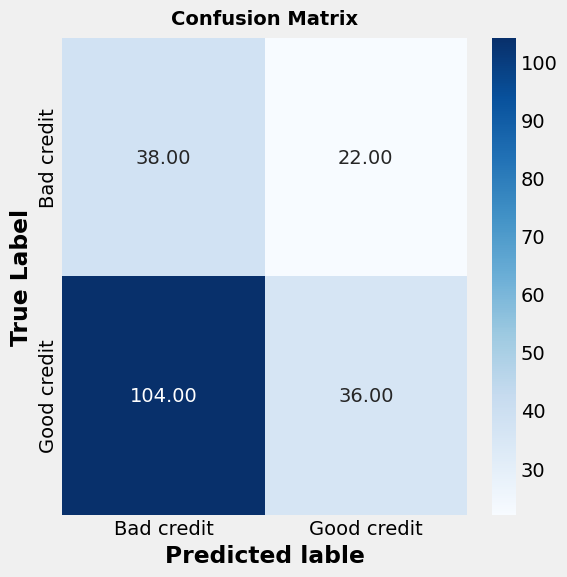

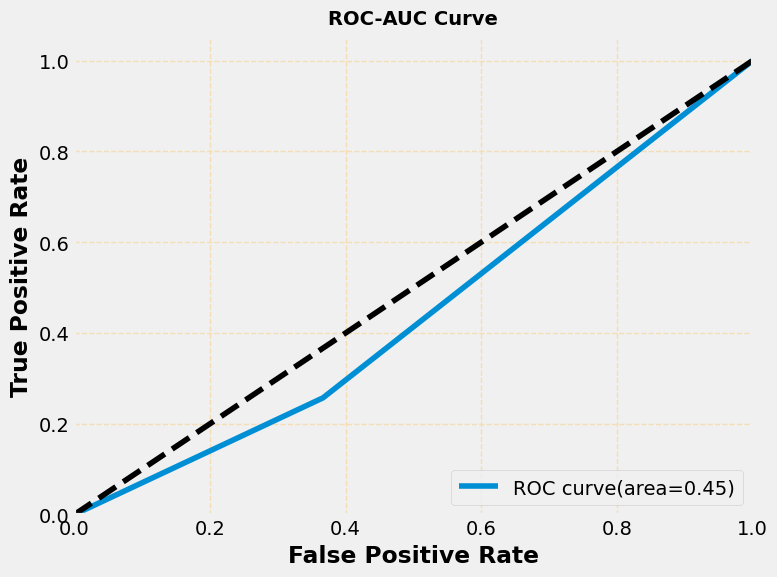

AUC score: 0.4452380952380952


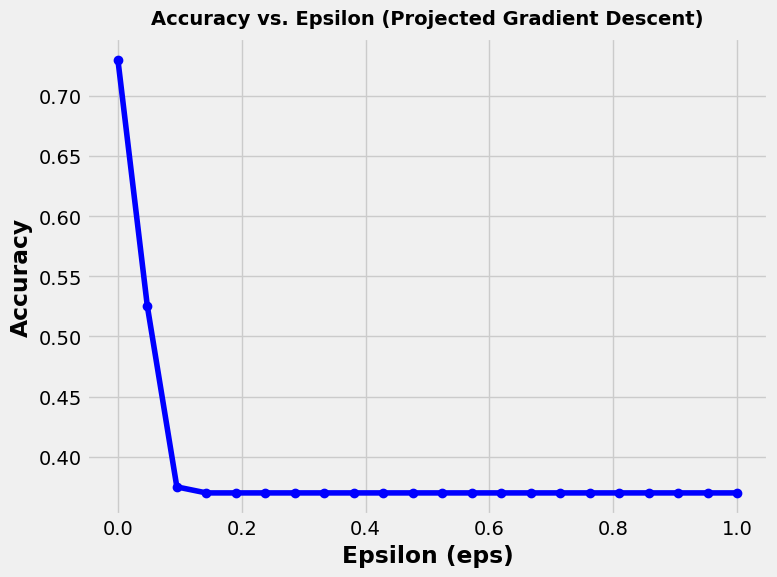

In [137]:
# Wrap the trained PyTorch model with ART PyTorch Classifier
classifier = create_classifier(best_model.model, best_model.loss_fn, best_model.optimizer, input_shape, nb_classes)

# Evaluate Projected Gradient Descent attack
pgd_attack = ProjectedGradientDescent
accuracies_pgd = evaluate_attack(pgd_attack, X_test, y_test, classifier, eps_values)

# Plot results
plt.figure(figsize=(8, 6))
plt.plot(eps_values, accuracies_pgd, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Epsilon (Projected Gradient Descent)')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### 4.3.4 Boundary Attack

Boundary attack:   0%|          | 0/200 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Boundary attack - iterations:   0%|          | 0/5000 [00:00<?, ?it/s]

Adversarial test data accuracy: 84.50%
              precision    recall  f1-score   support

           0       0.66      1.00      0.79        60
           1       1.00      0.78      0.88       140

    accuracy                           0.84       200
   macro avg       0.83      0.89      0.84       200
weighted avg       0.90      0.84      0.85       200



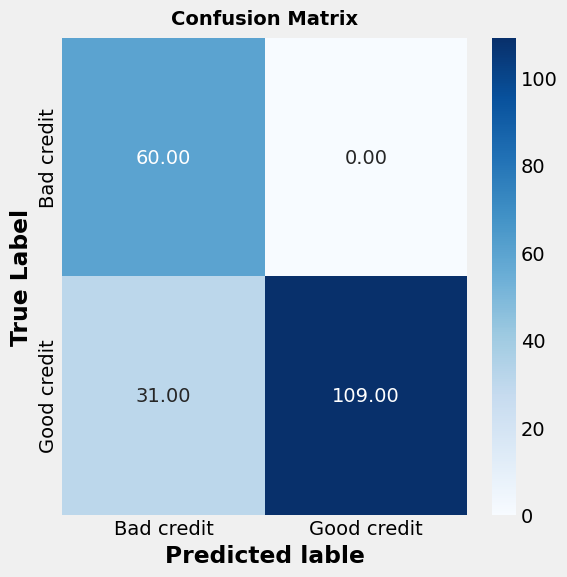

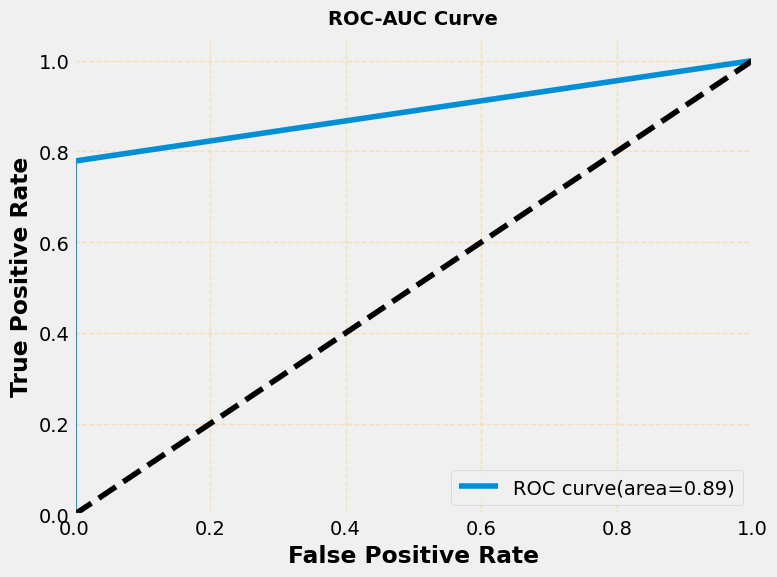

AUC score: 0.8892857142857142
Boundary attack accuracy: 84.50%


In [138]:
# Create a function to evaluate the attack
def evaluate_attack(attack, X_test, y_test, classifier):
    # Generate adversarial examples with target labels
    attack_instance = attack(estimator=classifier)
    X_test_adv = attack_instance.generate(x=X_test, y=y_test)
    
    # Test accuracy on adversarial samples
    predictions_adv = classifier.predict(X_test_adv)
    predictions_adv_binary = np.where(predictions_adv[:, 1] > 0.5, 1, 0)
    accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
    print(f"Adversarial test data accuracy: {accuracy_adv * 100:.2f}%")
    print(classification_report(y_test, predictions_adv_binary))

    
    confusion_matri(y_test, predictions_adv_binary)

    #### ROC Curve
    draw_roc(y_test, predictions_adv_binary)
    auc = roc_auc_score(y_test, predictions_adv_binary)
    print(f"AUC score: {auc}") 
    
    return accuracy_adv

# Wrap the trained PyTorch model with ART PyTorch Classifier
classifier = create_classifier(best_model.model, best_model.loss_fn, best_model.optimizer, input_shape, nb_classes)

# Evaluate Boundary Attack
boundary_attack = BoundaryAttack
accuracy_boundary = evaluate_attack(boundary_attack, X_test, y_test, classifier)
print(f"Boundary attack accuracy: {accuracy_boundary * 100:.2f}%")

## 4.4 Countermeasures Exploration

### 4.4.1 Training the model with the adversarial dataset

Original test data accuracy: 59.50%
Adversarial test data accuracy: 46.00%


Precompute adv samples:   0%|          | 0/1 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Defended test data accuracy: 81.00%
Defended adversarial test data accuracy: 72.00%


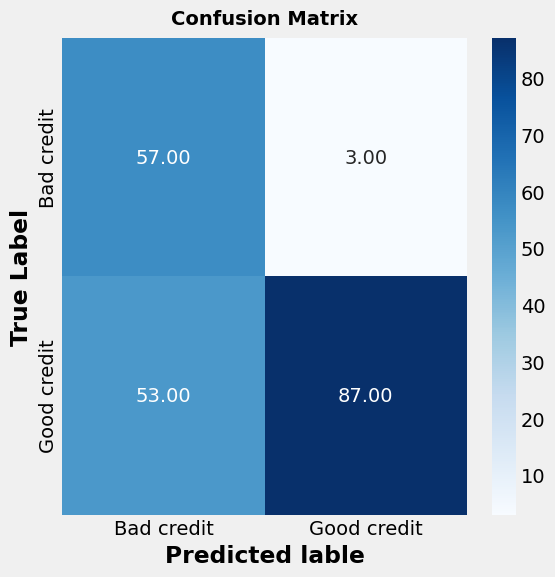

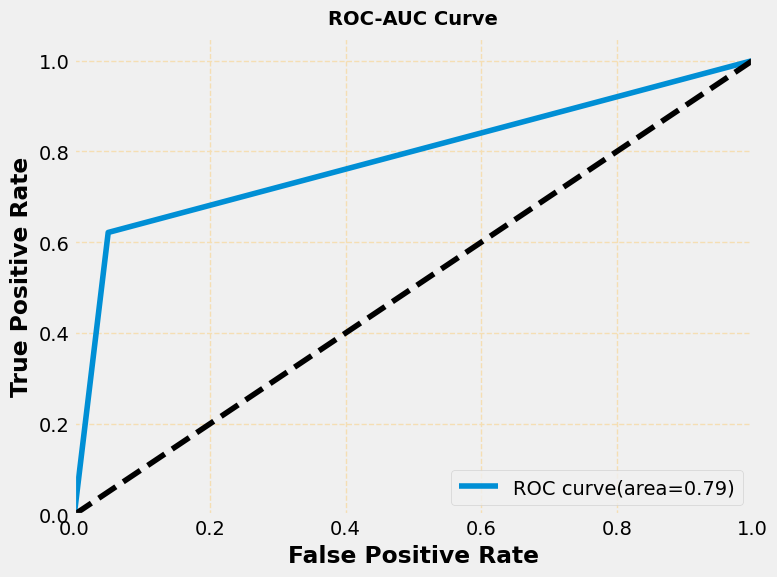

AUC score: 0.7857142857142857


In [140]:
# Wrap the trained PyTorch model with ART PyTorchClassifier
classifier = ARTClassifier(
    model=best_model.model,
    loss=best_model.loss_fn,
    optimizer=best_model.optimizer,
    input_shape=(X.shape[1],),
    nb_classes=2,
    clip_values=(0, 1)  # Assuming your data is normalized between 0 and 1
)

# Convert test data to float32
X_test = X_test.astype(np.float32)

# Test the model's accuracy on the original test samples
predictions = classifier.predict(X_test)
predictions_binary = np.where(predictions[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy = accuracy_score(y_test, predictions_binary)
print(f"Original test data accuracy: {accuracy * 100:.2f}%")

# Eseguire un attacco di evasione (FGSM) sui campioni di test
attack = FastGradientMethod(estimator=classifier, norm=2, eps=0.3)
X_test_adv = attack.generate(x=X_test)  # Genera esempi adversariali

# Test dell'accuratezza del modello sui campioni di test adversariali
predictions_adv = classifier.predict(X_test_adv)
predictions_adv_binary = np.where(predictions_adv[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
print(f"Adversarial test data accuracy: {accuracy_adv * 100:.2f}%")

# Difendere il modello contro l'attacco di evasione usando l'adversarial training
adv_trainer = AdversarialTrainer(classifier, attacks=attack, ratio=0.5)
adv_trainer.fit(x=X_test, y=y_test, batch_size=100, nb_epochs=10)

# Rivalutare l'accuratezza del modello sui campioni di test originali dopo l'adversarial training
predictions_def = classifier.predict(X_test)
predictions_def_binary = np.where(predictions_def[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy_def = accuracy_score(y_test, predictions_def_binary)
print(f"Defended test data accuracy: {accuracy_def * 100:.2f}%")

# Rivalutare l'accuratezza del modello sui campioni di test adversariali dopo l'adversarial training
predictions_adv_def = classifier.predict(X_test_adv)
predictions_adv_def_binary = np.where(predictions_adv_def[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy_adv_def = accuracy_score(y_test, predictions_adv_def_binary)
print(f"Defended adversarial test data accuracy: {accuracy_adv_def * 100:.2f}%")
confusion_matri(y_test, predictions_adv_def_binary)

#### ROC Curve
draw_roc(y_test, predictions_adv_def_binary)
auc = roc_auc_score(y_test, predictions_adv_def_binary)
print(f"AUC score: {auc}") 